In [1]:
# original train dataset: "dataset/original/train_dataset.csv"
# DAE train dataset: "dataset/synthetic/dae_synthetic_dataset.csv"

# and test the original train dataset and the DAE dataset on the original test dataset "dataset/original/test_dataset.csv

# print following evaluation values for each trained dataset: Macro_f1, Reconstruction_Error, test_loss, validation _loss, ROC


In [2]:
#Cell 1
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, log_loss, mean_squared_error, roc_auc_score

# File paths
orig_train_path = "dataset/original/train_dataset.csv"
dae_train_path = "dataset/synthetic/dae_synthetic_dataset.csv"
tabgan_train_path = "dataset/synthetic/tabgan_synthetic_dataset.csv"
orig_test_path = "dataset/original/test_dataset.csv"

# Load datasets
df_orig_train = pd.read_csv(orig_train_path)
df_dae_train = pd.read_csv(dae_train_path)
df_tabgan_train = pd.read_csv(tabgan_train_path)
df_orig_test = pd.read_csv(orig_test_path)

print(f"Original Train shape: {df_orig_train.shape}")
print(f"DAE Train shape:      {df_dae_train.shape}")
print(f"TabGAN Train shape:   {df_tabgan_train.shape}")
print(f"Original Test shape:  {df_orig_test.shape}")

Original Train shape: (34311, 10)
DAE Train shape:      (34312, 6)
TabGAN Train shape:   (34312, 6)
Original Test shape:  (14706, 10)


In [3]:
#Cell 2
target_col = "Attack"
features_to_keep = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]

def preprocess_dataset(df, label_encoder=None, is_train=True):
    # Filter features + target
    cols = [c for c in features_to_keep if c in df.columns] + [target_col]
    df_filtered = df[cols].copy()
    
    # One-hot encode 'State'
    if "State" in df_filtered.columns:
        df_filtered = pd.get_dummies(df_filtered, columns=["State"], drop_first=False)
    
    # Ensure all State columns are present
    for state_val in ["idle", "charging"]:
        col_name = f"State_{state_val}"
        if col_name not in df_filtered.columns:
            df_filtered[col_name] = 0

    # Encode target labels
    if is_train:
        label_encoder = LabelEncoder()
        y = label_encoder.fit_transform(df_filtered[target_col])
    else:
        y = label_encoder.transform(df_filtered[target_col])
        
    X = df_filtered.drop(columns=[target_col])
    
    return X, y, label_encoder

# Encode target classes consistently across all splits
X_orig_train, y_orig_train, le = preprocess_dataset(df_orig_train, is_train=True)
X_dae_train, y_dae_train, _ = preprocess_dataset(df_dae_train, label_encoder=le, is_train=False)
X_tabgan_train, y_tabgan_train, _ = preprocess_dataset(df_tabgan_train, label_encoder=le, is_train=False)
X_orig_test, y_orig_test, _ = preprocess_dataset(df_orig_test, label_encoder=le, is_train=False)

# Ensure feature column alignment across all datasets
feature_order = X_orig_train.columns.tolist()
X_dae_train = X_dae_train[feature_order]
X_tabgan_train = X_tabgan_train[feature_order]
X_orig_test = X_orig_test[feature_order]

# Scale numeric features per training dataset & fit test scalers
scaler_orig = StandardScaler()
X_orig_train_scaled = scaler_orig.fit_transform(X_orig_train)
X_orig_test_scaled_orig = scaler_orig.transform(X_orig_test)

scaler_dae = StandardScaler()
X_dae_train_scaled = scaler_dae.fit_transform(X_dae_train)
X_orig_test_scaled_dae = scaler_dae.transform(X_orig_test)

scaler_tabgan = StandardScaler()
X_tabgan_train_scaled = scaler_tabgan.fit_transform(X_tabgan_train)
X_orig_test_scaled_tabgan = scaler_tabgan.transform(X_orig_test)

print("Data alignment and scaling completed for Original, DAE, and TabGAN.")
print(f"Target classes encoded as: {dict(zip(le.classes_, range(len(le.classes_))))}")

Data alignment and scaling completed for Original, DAE, and TabGAN.
Target classes encoded as: {'Backdoor': 0, 'none': 1, 'syn-flood': 2}


In [4]:
# Cell 3
def evaluate_model(model, X_train, y_train, X_test, y_test, dataset_name):
    """
    Evaluates the Random Forest model and stores final metrics:
    Macro_f1, Reconstruction_Error, train_loss, test_loss,
    validation_loss (based on OOB probabilities), and ROC-AUC.
    """
    
    # Predictions on train and test data
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)

    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)

    # Main metrics
    macro_f1 = f1_score(y_test, y_test_pred, average="macro")
    reconstruction_error = mean_squared_error(y_test, y_test_pred)

    # Loss metrics
    train_loss = log_loss(y_train, y_train_prob)
    test_loss = log_loss(y_test, y_test_prob)

    # OOB validation loss as validation proxy
    val_loss = None
    if hasattr(model, "oob_decision_function_") and model.oob_decision_function_ is not None:
        val_loss = log_loss(y_train, model.oob_decision_function_)

    # ROC-AUC
    roc_auc = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average="macro")

    print("==========================================")
    print(f" Evaluation Metrics for: {dataset_name}")
    print("==========================================")
    print(f"  Macro_f1:             {macro_f1:.6f}")
    print(f"  Reconstruction_Error: {reconstruction_error:.6f}")
    print(f"  train_loss:           {train_loss:.6f}")
    print(f"  test_loss:            {test_loss:.6f}")
    if val_loss is not None:
        print(f"  validation_loss:      {val_loss:.6f}")
    else:
        print("  validation_loss:      Not available (oob_score=False)")
    print(f"  ROC_AUC:              {roc_auc:.6f}\n")

    return {
        "Dataset": dataset_name,
        "Macro_f1": macro_f1,
        "Reconstruction_Error": reconstruction_error,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "validation_loss": val_loss,
        "ROC": roc_auc
    }

In [5]:
#Cell 4
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

def extract_additional_metrics(model, X_test, y_test, feature_names):
    """Helper to extract feature importances and confusion matrix raw values."""
    importances = dict(zip(feature_names, model.feature_importances_))
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    return importances, cm

def get_state_feature_breakdown(model, X_test_unscaled, scaler, feature_names, le):
    """
    Computes feature averages per predicted attack class using unscaled features,
    separated cleanly by binary State (idle vs charging).
    """
    # Scale test data for model inference
    X_test_scaled = scaler.transform(X_test_unscaled[feature_names])
    y_pred = model.predict(X_test_scaled)
    pred_labels = le.inverse_transform(y_pred)
    
    # Work on unscaled data for clean filtering and readable original units
    df_analysis = X_test_unscaled.copy()
    df_analysis['Predicted_Attack'] = pred_labels
    
    continuous_features = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
    
    # State: idle matrix
    idle_mask = df_analysis['State_idle'] == 1
    df_idle = df_analysis[idle_mask]
    matrix_idle = df_idle.groupby('Predicted_Attack')[continuous_features].mean().T
    
    # State: charging matrix
    charging_mask = df_analysis['State_charging'] == 1
    df_charging = df_analysis[charging_mask]
    matrix_charging = df_charging.groupby('Predicted_Attack')[continuous_features].mean().T
    
    # Ensure all target attack classes appear on the X-axis
    for attack in le.classes_:
        if attack not in matrix_idle.columns:
            matrix_idle[attack] = np.nan
        if attack not in matrix_charging.columns:
            matrix_charging[attack] = np.nan
            
    matrix_idle = matrix_idle[list(le.classes_)]
    matrix_charging = matrix_charging[list(le.classes_)]
    
    return matrix_idle, matrix_charging

# Feature names list from encoded data
feature_names = feature_order

# 1. Train & Evaluate on Original Dataset
rf_orig = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)
rf_orig.fit(X_orig_train_scaled, y_orig_train)

metrics_orig = evaluate_model(
    rf_orig, 
    X_orig_train_scaled, 
    y_orig_train, 
    X_orig_test_scaled_orig, 
    y_orig_test, 
    "Original Train Dataset"
)

importances_orig, cm_orig = extract_additional_metrics(
    rf_orig, X_orig_test_scaled_orig, y_orig_test, feature_names
)
metrics_orig["Feature_Importances"] = importances_orig
metrics_orig["Confusion_Matrix"] = cm_orig.tolist()

# 2. Train & Evaluate on DAE Synthetic Dataset
rf_dae = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)
rf_dae.fit(X_dae_train_scaled, y_dae_train)

metrics_dae = evaluate_model(
    rf_dae, 
    X_dae_train_scaled, 
    y_dae_train, 
    X_orig_test_scaled_dae, 
    y_orig_test, 
    "DAE Synthetic Dataset"
)

importances_dae, cm_dae = extract_additional_metrics(
    rf_dae, X_orig_test_scaled_dae, y_orig_test, feature_names
)
metrics_dae["Feature_Importances"] = importances_dae
metrics_dae["Confusion_Matrix"] = cm_dae.tolist()

# 3. Train & Evaluate on TabGAN Synthetic Dataset
rf_tabgan = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)
rf_tabgan.fit(X_tabgan_train_scaled, y_tabgan_train)

metrics_tabgan = evaluate_model(
    rf_tabgan, 
    X_tabgan_train_scaled, 
    y_tabgan_train, 
    X_orig_test_scaled_tabgan, 
    y_orig_test, 
    "TabGAN Synthetic Dataset"
)

importances_tabgan, cm_tabgan = extract_additional_metrics(
    rf_tabgan, X_orig_test_scaled_tabgan, y_orig_test, feature_names
)
metrics_tabgan["Feature_Importances"] = importances_tabgan
metrics_tabgan["Confusion_Matrix"] = cm_tabgan.tolist()

# --- Print Feature Importances and Confusion Matrices ---
print("==========================================")
print(" Feature Importances & Confusion Matrices ")
print("==========================================")

for name, imp, cm in [
    ("Original Dataset", importances_orig, cm_orig),
    ("DAE Synthetic Dataset", importances_dae, cm_dae),
    ("TabGAN Synthetic Dataset", importances_tabgan, cm_tabgan)
]:
    print(f"\n--- {name} ---")
    print("Feature Importances:")
    for feat, val in sorted(imp.items(), key=lambda x: x[1], reverse=True):
        print(f"  {feat:18s}: {val:.4f}")
        
    print("\nConfusion Matrix (Raw Values):")
    print(f"  Classes: {list(le.classes_)}")
    print(cm)

# --- Print State Breakdown Matrices (Features vs Attacks) ---
print("\n==================================================")
print(" Feature vs Attack Matrices (Split by State) ")
print("==================================================")

matrix_idle_orig, matrix_charging_orig = get_state_feature_breakdown(
    rf_orig, X_orig_test, scaler_orig, feature_names, le
)
matrix_idle_dae, matrix_charging_dae = get_state_feature_breakdown(
    rf_dae, X_orig_test, scaler_dae, feature_names, le
)
matrix_idle_tabgan, matrix_charging_tabgan = get_state_feature_breakdown(
    rf_tabgan, X_orig_test, scaler_tabgan, feature_names, le
)

print("\n--- [Original Dataset Model] State: Idle ---")
print(matrix_idle_orig.round(4))

print("\n--- [Original Dataset Model] State: Charging ---")
print(matrix_charging_orig.round(4))

print("\n--- [DAE Synthetic Model] State: Idle ---")
print(matrix_idle_dae.round(4))

print("\n--- [DAE Synthetic Model] State: Charging ---")
print(matrix_charging_dae.round(4))

print("\n--- [TabGAN Synthetic Model] State: Idle ---")
print(matrix_idle_tabgan.round(4))

print("\n--- [TabGAN Synthetic Model] State: Charging ---")
print(matrix_charging_tabgan.round(4))

# Summary Comparison Table
summary_cols = ["Dataset", "Macro_f1", "Reconstruction_Error", "test_loss", "validation_loss", "ROC"]
results_df = pd.DataFrame([metrics_orig, metrics_dae, metrics_tabgan])

print("\n--- Final Summary Comparison ---")
print(results_df[summary_cols].to_string(index=False))


import joblib
import os

models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

joblib.dump(rf_orig, f"{models_dir}/rf_orig.pkl")
joblib.dump(rf_dae,  f"{models_dir}/rf_dae.pkl")
joblib.dump(rf_tabgan, f"{models_dir}/rf_tabgan.pkl")

print("RF models saved to:")
print(f"  {models_dir}/rf_orig.pkl")
print(f"  {models_dir}/rf_dae.pkl")
print(f"  {models_dir}/rf_tabgan.pkl")

 Evaluation Metrics for: Original Train Dataset
  Macro_f1:             0.870052
  Reconstruction_Error: 0.218958
  train_loss:           0.075104
  test_loss:            0.419107
  validation_loss:      0.553898
  ROC_AUC:              0.965127

 Evaluation Metrics for: DAE Synthetic Dataset
  Macro_f1:             0.772665
  Reconstruction_Error: 0.372161
  train_loss:           0.029257
  test_loss:            1.039075
  validation_loss:      0.126885
  ROC_AUC:              0.922102

 Evaluation Metrics for: TabGAN Synthetic Dataset
  Macro_f1:             0.919831
  Reconstruction_Error: 0.136815
  train_loss:           0.066796
  test_loss:            0.268931
  validation_loss:      0.427223
  ROC_AUC:              0.982350

 Feature Importances & Confusion Matrices 

--- Original Dataset ---
Feature Importances:
  shunt_voltage     : 0.2704
  current_mA        : 0.2430
  power_mW          : 0.2121
  bus_voltage_V     : 0.1816
  State_idle        : 0.0467
  State_charging    : 0

In [93]:
#PLOTS

/tmp/ipykernel_14460/360353473.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_14460/360353473.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=20, fontsize=10)
/tmp/ipykernel_14460/360353473.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_14460/360353473.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, rotation=20, fontsize=10)
/tmp/ipykernel_14460/360353473.py:29: FutureWarning: 

Passing `palette` wit

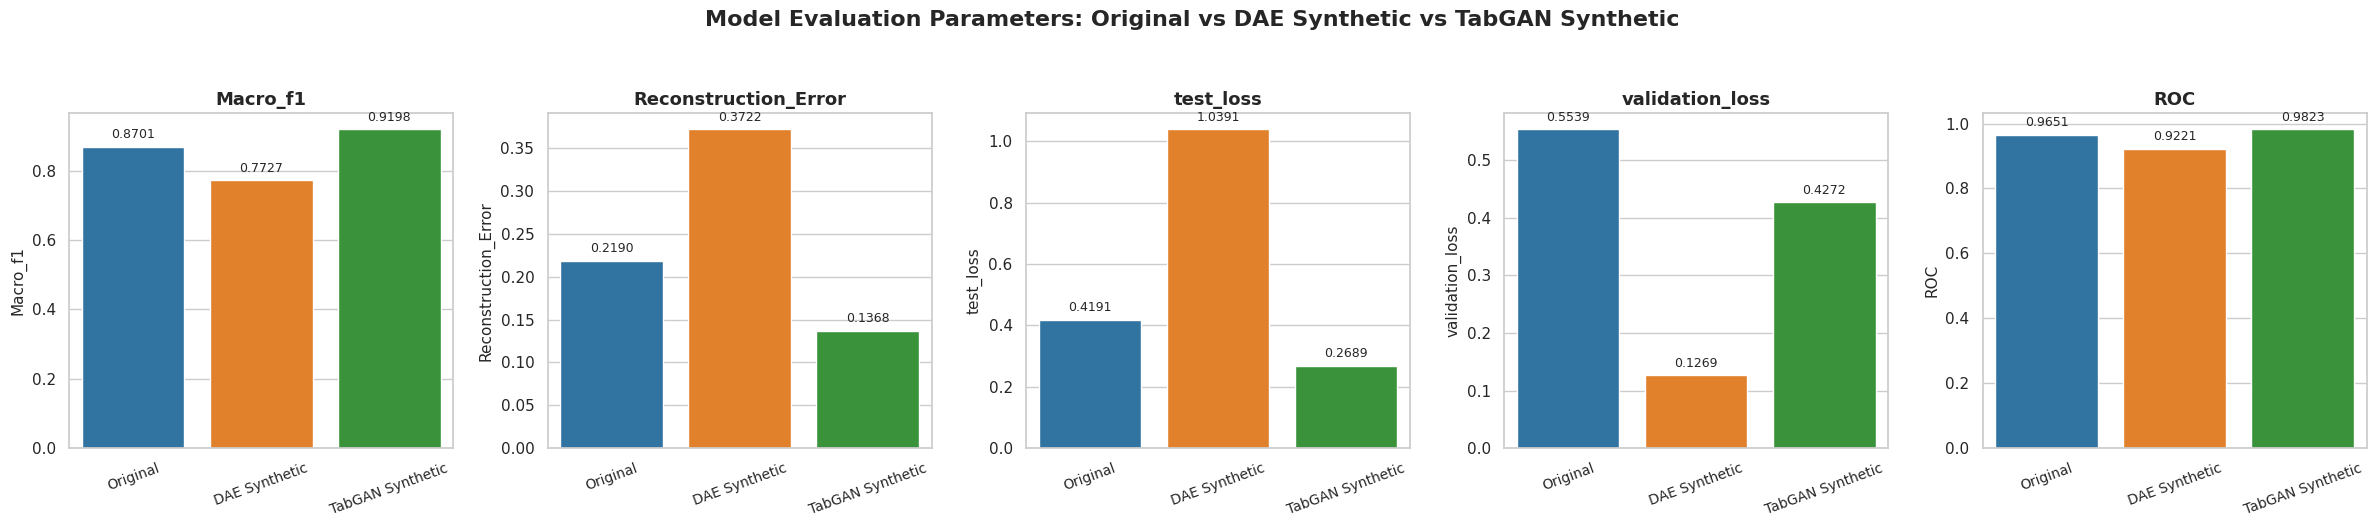

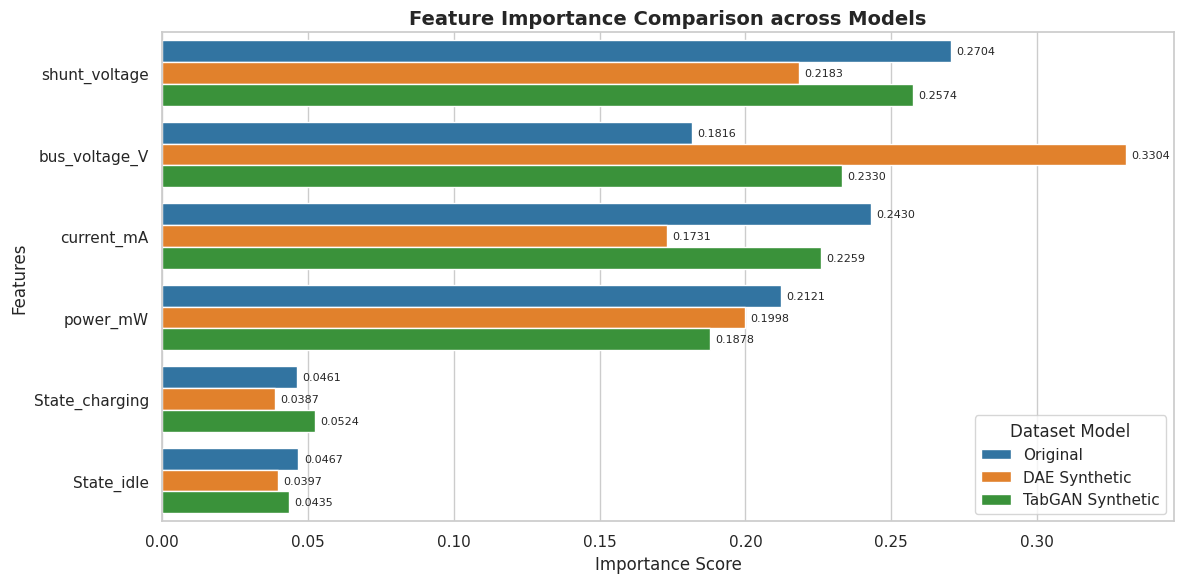

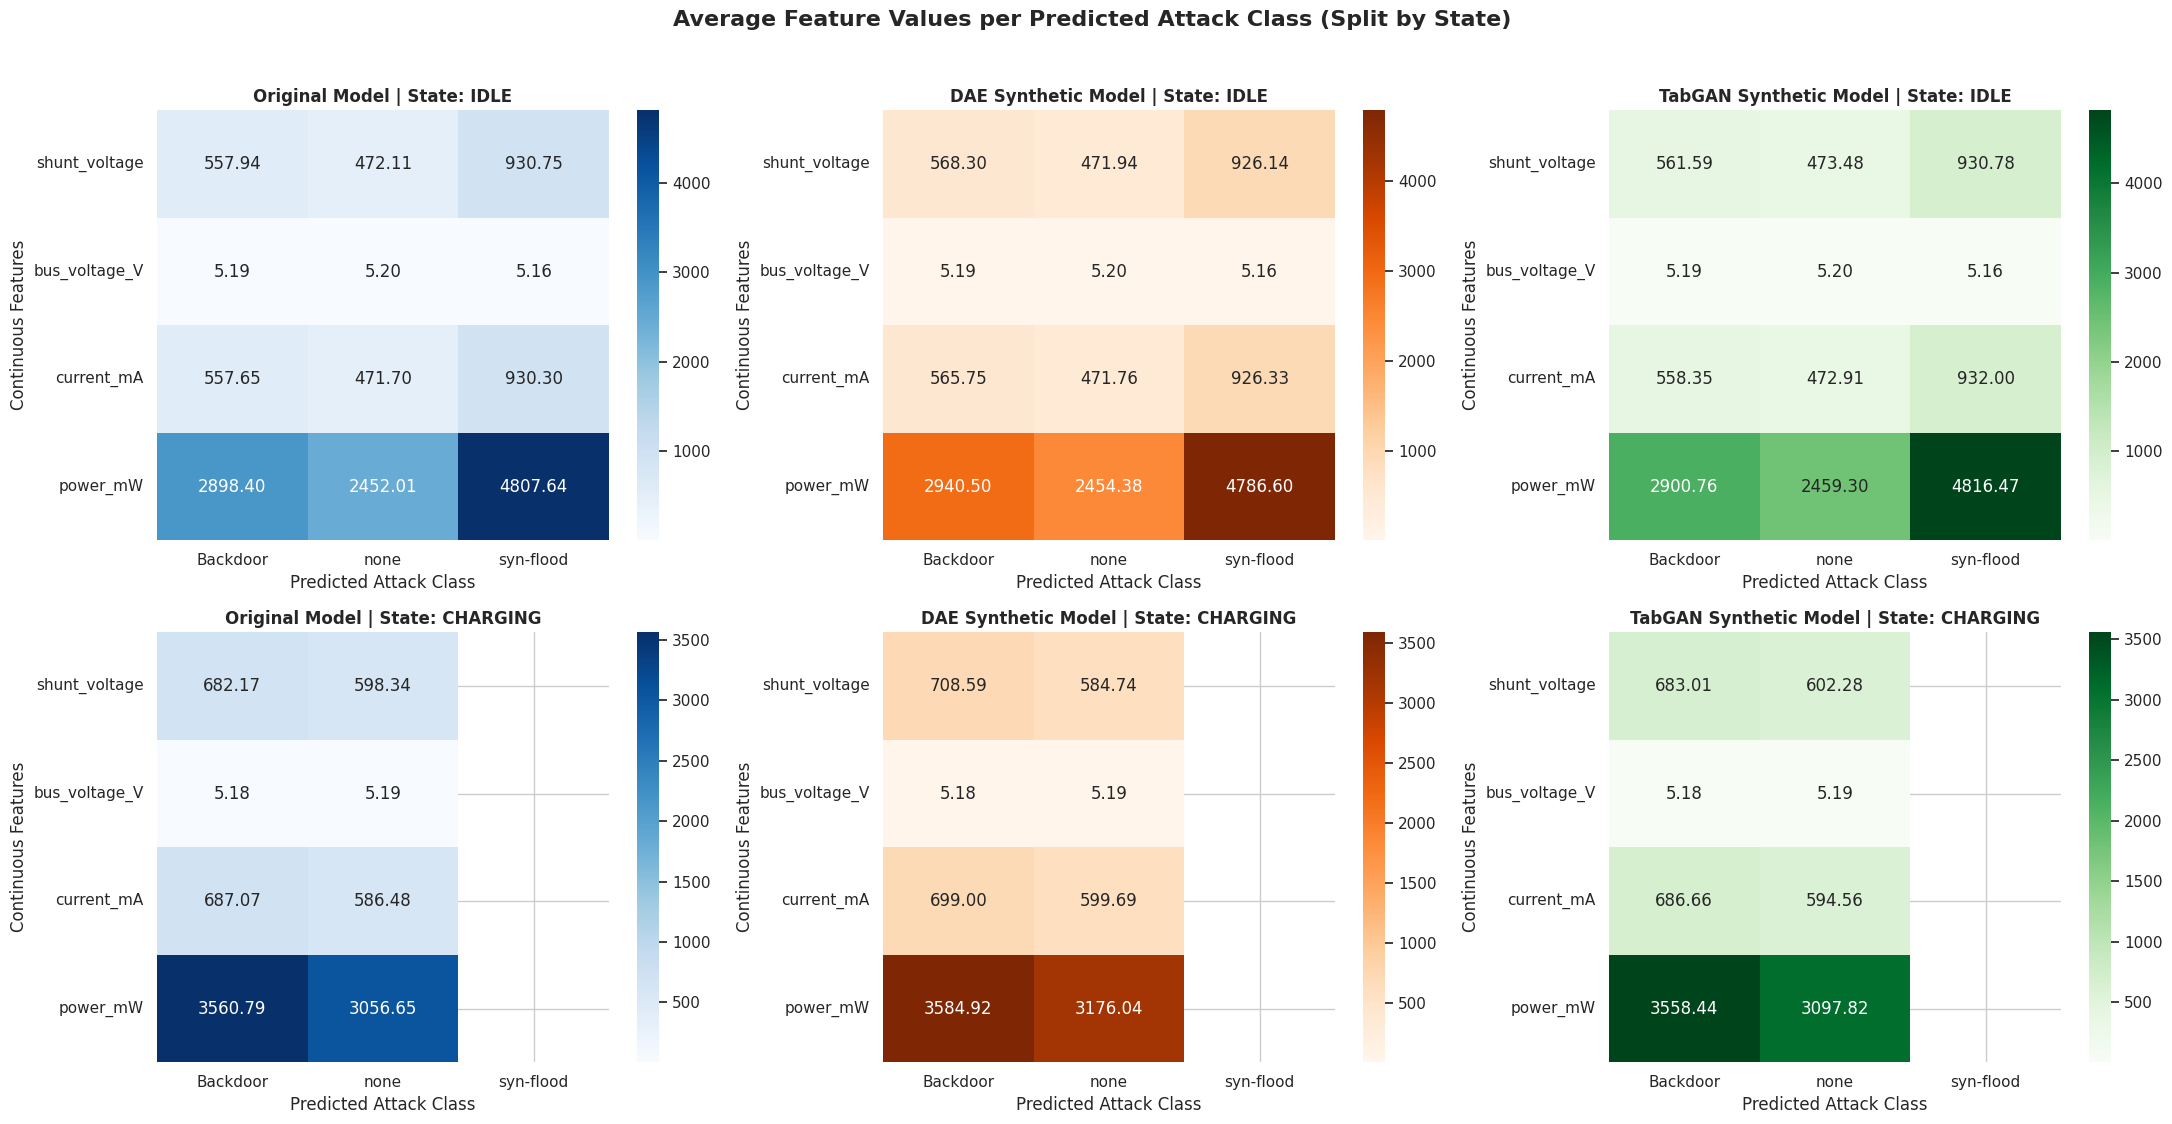

In [94]:
#Cell 5
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set visual style
sns.set_theme(style="whitegrid")

# Define consistent color palette for the 3 datasets
palette_3 = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# Helper to clean dataset names for plot labels
def clean_dataset_label(name):
    if "Original" in name:
        return "Original"
    elif "DAE" in name:
        return "DAE Synthetic"
    elif "TabGAN" in name:
        return "TabGAN Synthetic"
    return name

# --- Part 1: Plot Evaluation Metrics ---
metrics_list = ["Macro_f1", "Reconstruction_Error", "test_loss", "validation_loss", "ROC"]

fig, axes = plt.subplots(1, len(metrics_list), figsize=(24, 5))

for i, metric in enumerate(metrics_list):
    ax = axes[i]
    sns.barplot(
        data=results_df, 
        x="Dataset", 
        y=metric, 
        ax=ax, 
        palette=palette_3
    )
    ax.set_title(f"{metric}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(metric, fontsize=11)
    
    # Format X tick labels cleanly
    xticklabels = [clean_dataset_label(label.get_text()) for label in ax.get_xticklabels()]
    ax.set_xticklabels(xticklabels, rotation=20, fontsize=10)
    
    # Annotate numerical values on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.4f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center", 
            va="bottom", 
            fontsize=9, 
            xytext=(0, 4),
            textcoords="offset points"
        )

plt.suptitle("Model Evaluation Parameters: Original vs DAE Synthetic vs TabGAN Synthetic", fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

# --- Part 2: Plot Feature Importance Comparison ---
fi_rows = []
for row in results_df.itertuples():
    dataset_name = clean_dataset_label(row.Dataset)
    for feat_name, imp_val in row.Feature_Importances.items():
        fi_rows.append({
            "Dataset": dataset_name,
            "Feature": feat_name,
            "Importance": imp_val
        })

df_fi = pd.DataFrame(fi_rows)

plt.figure(figsize=(12, 6))
ax_fi = sns.barplot(
    data=df_fi,
    y="Feature",
    x="Importance",
    hue="Dataset",
    palette=palette_3
)

# Annotate values on the horizontal bars
for p in ax_fi.patches:
    width = p.get_width()
    if width > 0:
        ax_fi.annotate(
            f"{width:.4f}",
            (width, p.get_y() + p.get_height() / 2.0),
            ha="left",
            va="center",
            fontsize=8,
            xytext=(4, 0),
            textcoords="offset points"
        )

plt.title("Feature Importance Comparison across Models", fontsize=14, fontweight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.legend(title="Dataset Model", loc="lower right")
plt.tight_layout()
plt.show()

# --- Part 3: Heatmaps for Features vs Attacks Split by State (2x3 Grid) ---
fig, axes = plt.subplots(2, 3, figsize=(22, 11))

# Row 1: State IDLE
sns.heatmap(matrix_idle_orig, ax=axes[0, 0], annot=True, fmt=".2f", cmap="Blues", cbar=True)
axes[0, 0].set_title("Original Model | State: IDLE", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Predicted Attack Class")
axes[0, 0].set_ylabel("Continuous Features")

sns.heatmap(matrix_idle_dae, ax=axes[0, 1], annot=True, fmt=".2f", cmap="Oranges", cbar=True)
axes[0, 1].set_title("DAE Synthetic Model | State: IDLE", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Predicted Attack Class")
axes[0, 1].set_ylabel("Continuous Features")

sns.heatmap(matrix_idle_tabgan, ax=axes[0, 2], annot=True, fmt=".2f", cmap="Greens", cbar=True)
axes[0, 2].set_title("TabGAN Synthetic Model | State: IDLE", fontsize=12, fontweight="bold")
axes[0, 2].set_xlabel("Predicted Attack Class")
axes[0, 2].set_ylabel("Continuous Features")

# Row 2: State CHARGING
sns.heatmap(matrix_charging_orig, ax=axes[1, 0], annot=True, fmt=".2f", cmap="Blues", cbar=True)
axes[1, 0].set_title("Original Model | State: CHARGING", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Predicted Attack Class")
axes[1, 0].set_ylabel("Continuous Features")

sns.heatmap(matrix_charging_dae, ax=axes[1, 1], annot=True, fmt=".2f", cmap="Oranges", cbar=True)
axes[1, 1].set_title("DAE Synthetic Model | State: CHARGING", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Predicted Attack Class")
axes[1, 1].set_ylabel("Continuous Features")

sns.heatmap(matrix_charging_tabgan, ax=axes[1, 2], annot=True, fmt=".2f", cmap="Greens", cbar=True)
axes[1, 2].set_title("TabGAN Synthetic Model | State: CHARGING", fontsize=12, fontweight="bold")
axes[1, 2].set_xlabel("Predicted Attack Class")
axes[1, 2].set_ylabel("Continuous Features")

plt.suptitle("Average Feature Values per Predicted Attack Class (Split by State)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

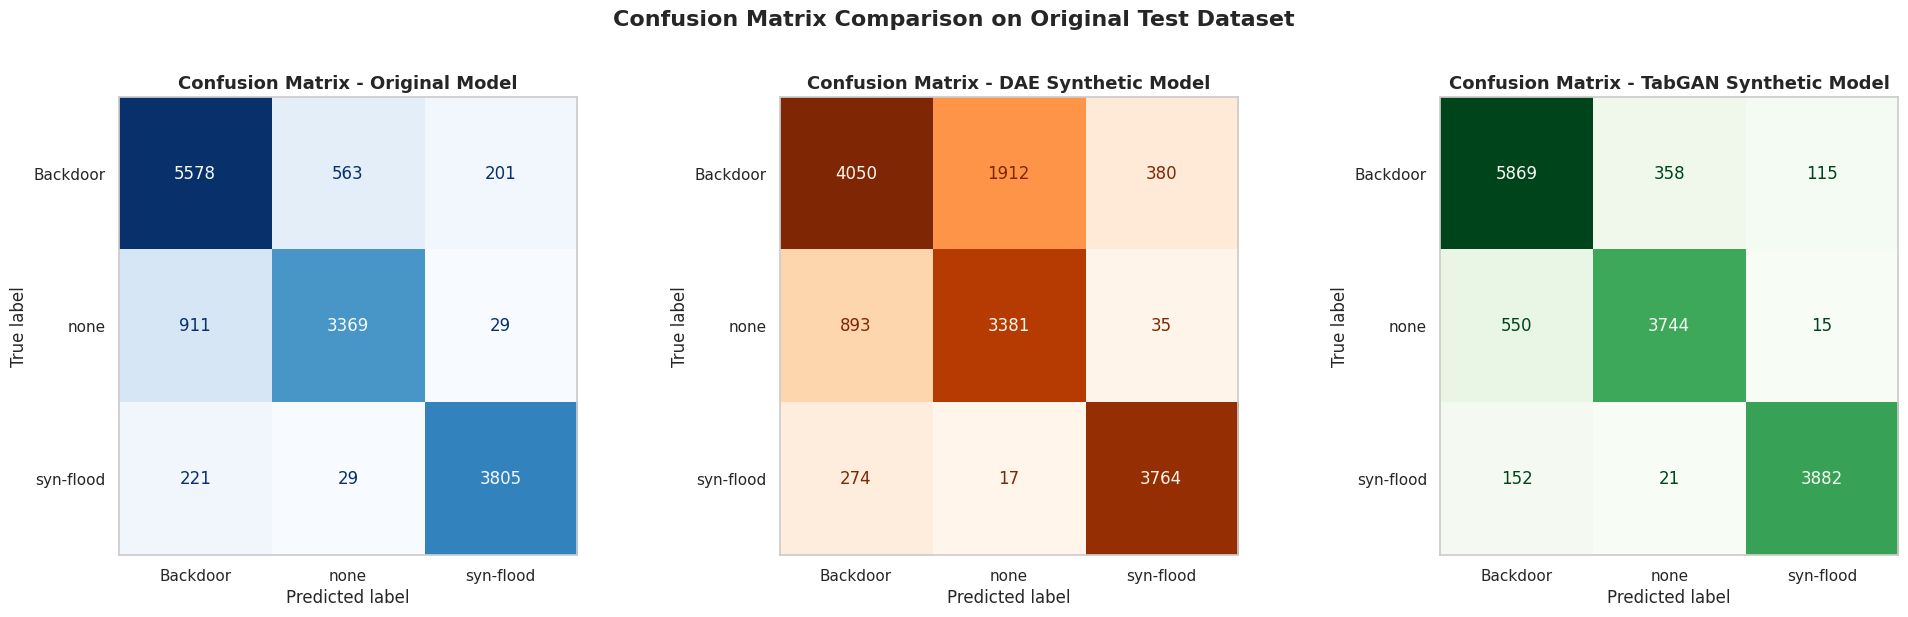

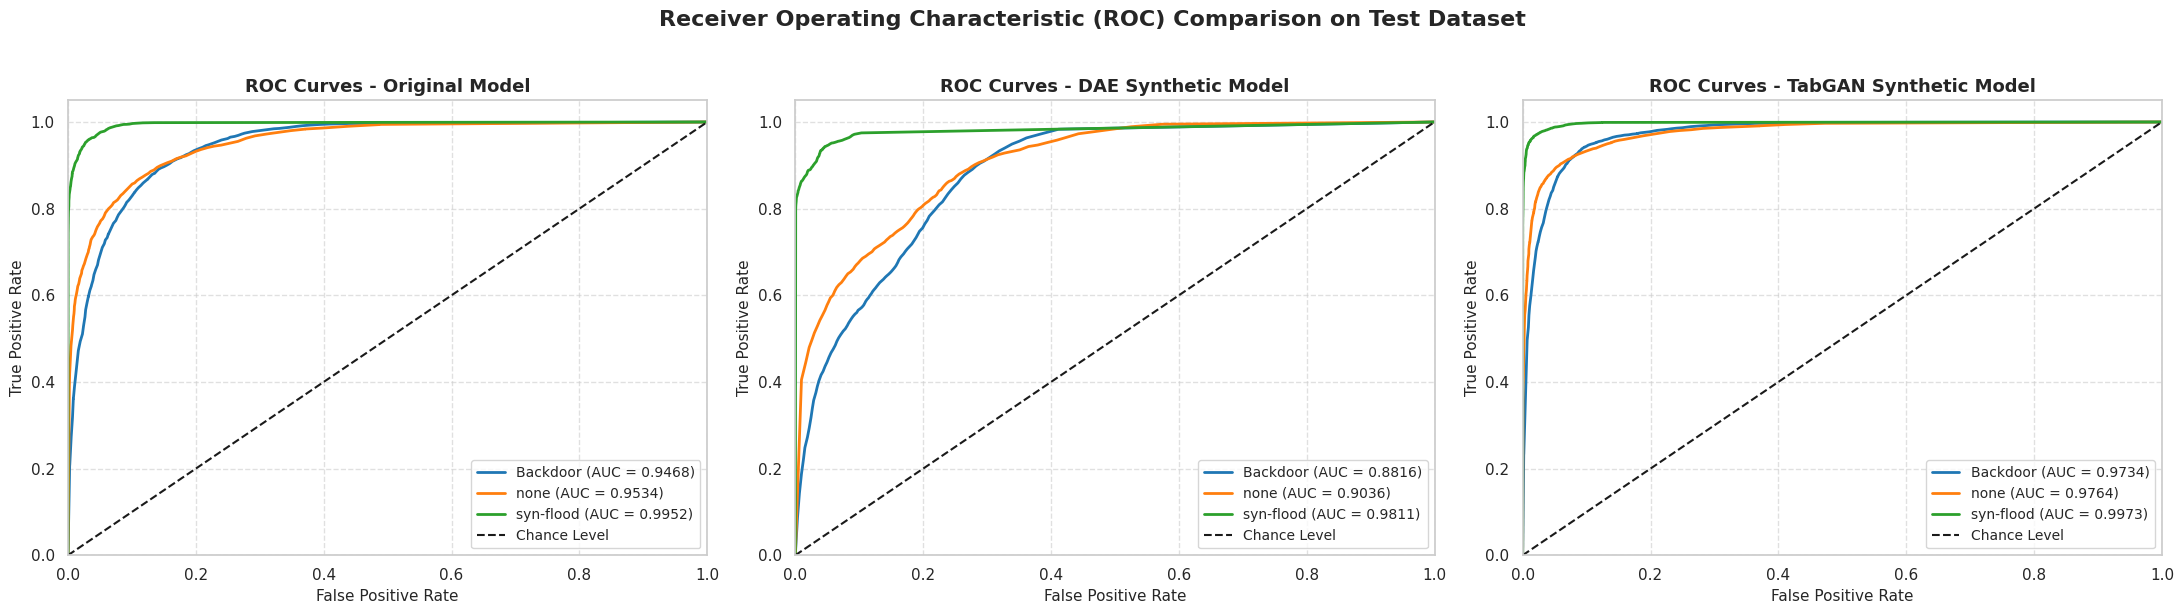

In [95]:
#Cell 6
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get predictions and predicted probabilities for all three models
y_pred_orig = rf_orig.predict(X_orig_test_scaled_orig)
y_prob_orig = rf_orig.predict_proba(X_orig_test_scaled_orig)

y_pred_dae = rf_dae.predict(X_orig_test_scaled_dae)
y_prob_dae = rf_dae.predict_proba(X_orig_test_scaled_dae)

y_pred_tabgan = rf_tabgan.predict(X_orig_test_scaled_tabgan)
y_prob_tabgan = rf_tabgan.predict_proba(X_orig_test_scaled_tabgan)

# Binarize labels for One-vs-Rest ROC calculation
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_orig_test, classes=range(n_classes))

# --- Part 1: Plot Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Original Model
cm_orig = confusion_matrix(y_orig_test, y_pred_orig)
disp_orig = ConfusionMatrixDisplay(confusion_matrix=cm_orig, display_labels=le.classes_)
disp_orig.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("Confusion Matrix - Original Model", fontsize=13, fontweight="bold")
axes[0].grid(False)

# 2. DAE Synthetic Model
cm_dae = confusion_matrix(y_orig_test, y_pred_dae)
disp_dae = ConfusionMatrixDisplay(confusion_matrix=cm_dae, display_labels=le.classes_)
disp_dae.plot(ax=axes[1], cmap="Oranges", values_format="d", colorbar=False)
axes[1].set_title("Confusion Matrix - DAE Synthetic Model", fontsize=13, fontweight="bold")
axes[1].grid(False)

# 3. TabGAN Synthetic Model
cm_tabgan = confusion_matrix(y_orig_test, y_pred_tabgan)
disp_tabgan = ConfusionMatrixDisplay(confusion_matrix=cm_tabgan, display_labels=le.classes_)
disp_tabgan.plot(ax=axes[2], cmap="Greens", values_format="d", colorbar=False)
axes[2].set_title("Confusion Matrix - TabGAN Synthetic Model", fontsize=13, fontweight="bold")
axes[2].grid(False)

plt.suptitle("Confusion Matrix Comparison on Original Test Dataset", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Part 2: Plot Multi-Class ROC Curves ---
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

models_data = [
    ("Original Model", y_prob_orig, axes[0]),
    ("DAE Synthetic Model", y_prob_dae, axes[1]),
    ("TabGAN Synthetic Model", y_prob_tabgan, axes[2])
]

for title, y_prob, ax in models_data:
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(
            fpr, tpr, color=colors[i % len(colors)], lw=2,
            label=f"{le.classes_[i]} (AUC = {roc_auc:.4f})"
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Chance Level")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=11)
    ax.set_ylabel("True Positive Rate", fontsize=11)
    ax.set_title(f"ROC Curves - {title}", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Receiver Operating Characteristic (ROC) Comparison on Test Dataset", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()




Original dataset table:

Attack         Backdoor  none  syn-flood
shunt_voltage     -0.25 -0.77       1.19
bus_voltage_V      0.25  0.81      -1.23
current_mA        -0.24 -0.79       1.19
power_mW          -0.24 -0.79       1.20
State              0.48  0.09      -0.87

DAE dataset table:

Attack         Backdoor  none  syn-flood
shunt_voltage     -0.23 -0.78       1.24
bus_voltage_V      0.25  0.82      -1.27
current_mA        -0.22 -0.78       1.24
power_mW          -0.23 -0.79       1.23
State              0.48  0.09      -0.87

TabGAN dataset table:

Attack         Backdoor  none  syn-flood
shunt_voltage     -0.26 -0.77       1.16
bus_voltage_V      0.26  0.82      -1.20
current_mA        -0.25 -0.79       1.14
power_mW          -0.21 -0.77       1.25
State              0.46  0.07      -0.89


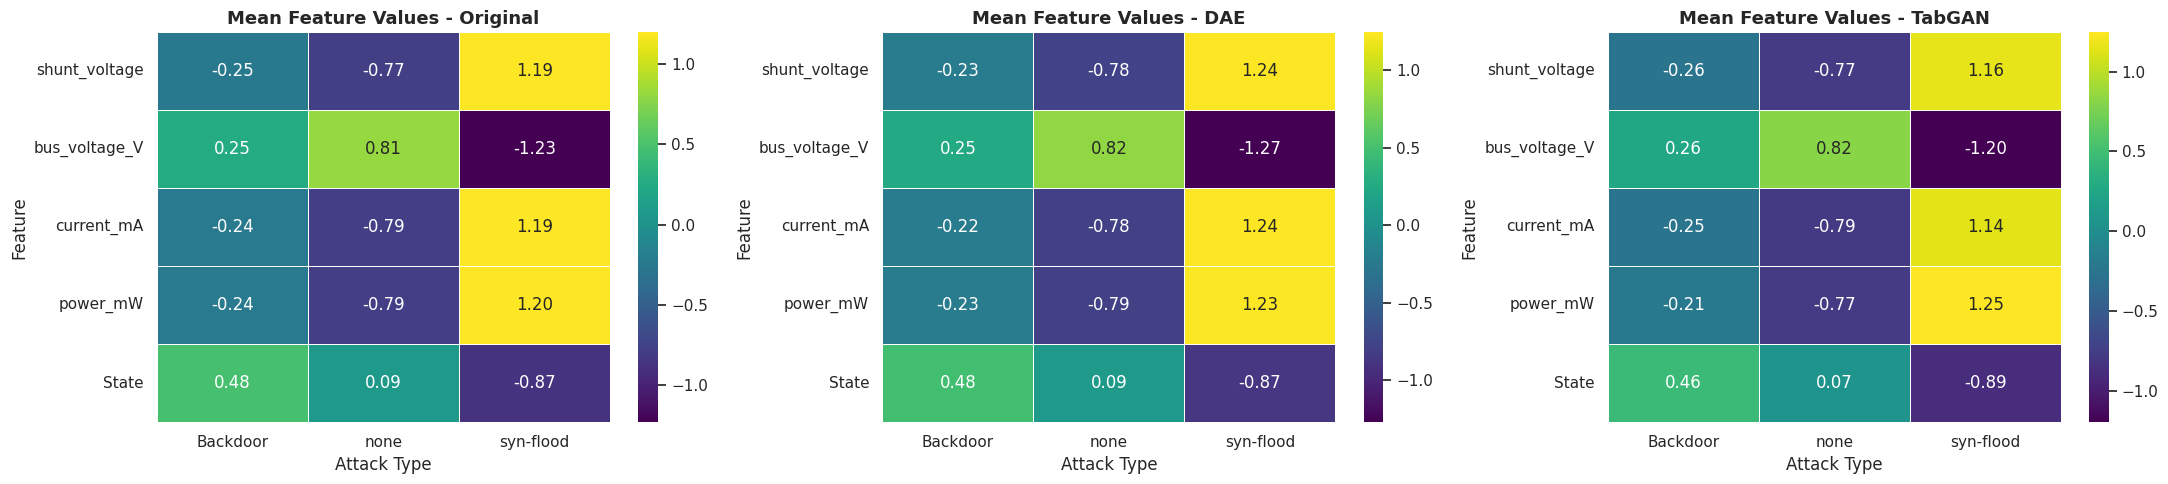

In [96]:
#Cell 7
# --- Part 3: Feature vs Attack-Type Heatmaps for All Datasets ---
feature_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW", "State"]
attack_order = ["Backdoor", "none", "syn-flood"]

def build_heatmap_df(X_data, y_data, feature_cols, attack_order):
    if isinstance(X_data, pd.DataFrame):
        plot_df = X_data[feature_cols].copy()
    else:
        plot_df = pd.DataFrame(X_data[:, :len(feature_cols)], columns=feature_cols)

    attack_labels = y_data
    if not isinstance(attack_labels, pd.Series):
        attack_labels = pd.Series(attack_labels)

    if np.issubdtype(attack_labels.dtype, np.number):
        attack_labels = pd.Series(le.inverse_transform(attack_labels.astype(int)))

    plot_df["Attack"] = attack_labels.values
    heatmap_df = plot_df.groupby("Attack")[feature_cols].mean().reindex(attack_order).T
    return heatmap_df

datasets = [
    ("Original", X_orig_test_scaled_orig, y_orig_test),
    ("DAE", X_orig_test_scaled_dae, y_orig_test),
    ("TabGAN", X_orig_test_scaled_tabgan, y_orig_test),
]

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

for ax, (name, X_data, y_data) in zip(axes, datasets):
    heatmap_data = build_heatmap_df(X_data, y_data, feature_cols, attack_order)

    sns.heatmap(
        heatmap_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f"Mean Feature Values - {name}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Attack Type")
    ax.set_ylabel("Feature")

    print(f"\n{name} dataset table:\n")
    print(heatmap_data.round(2).to_string())

plt.tight_layout()
plt.show()

/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sur

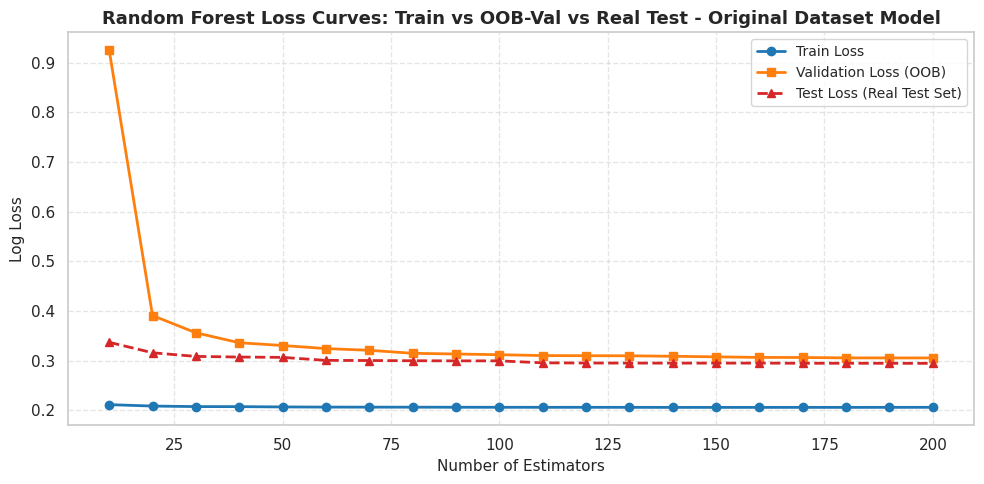

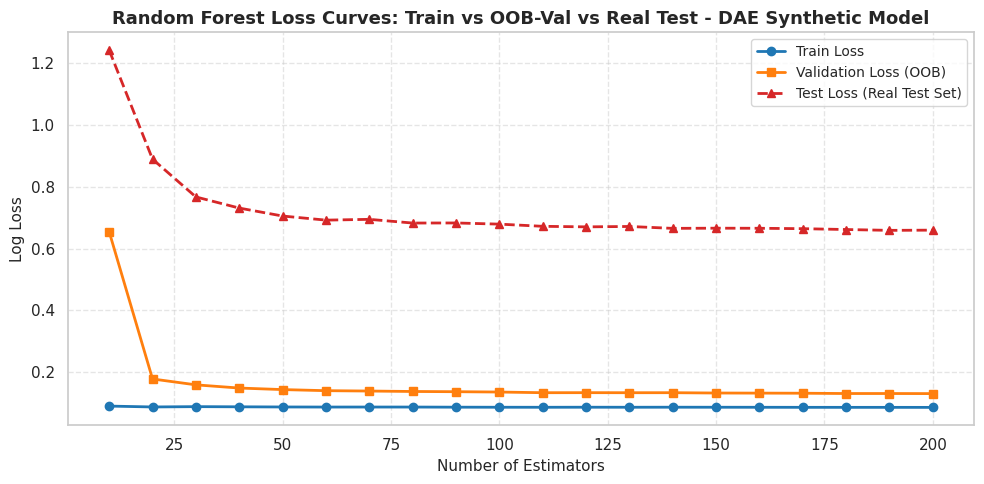

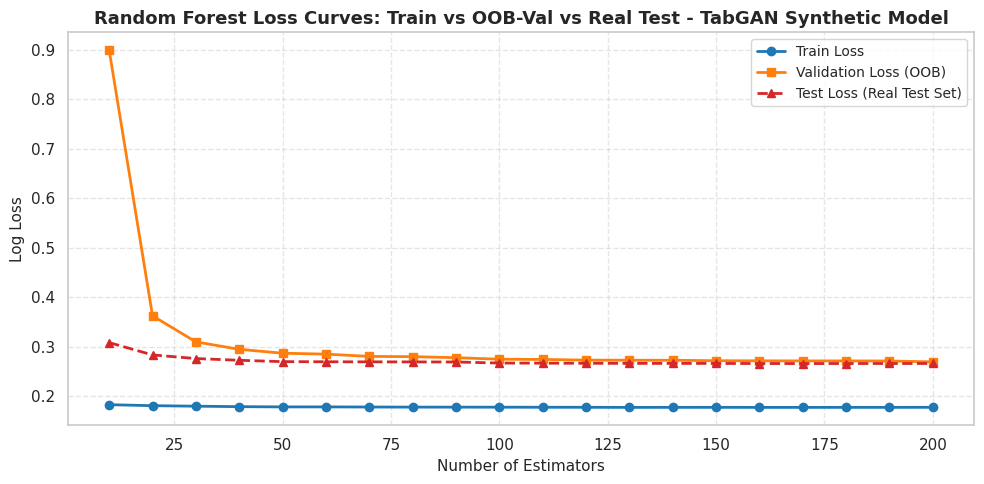

In [111]:
# Additional Cell (Updated): Train, OOB-Validation, and Real Test Loss curves over n_estimators
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss

SEED = 42

rf_params = {
    "bootstrap": True,
    "max_depth": None,
    "max_features": "sqrt",
    "min_samples_leaf": 1,
    "min_samples_split": 20,
    "criterion": "gini",
    "random_state": SEED,
    "n_jobs": -1,
    "oob_score": True,
    "warm_start": True
}

n_estimators_range = list(range(10, 201, 10))

def collect_rf_loss_curve_with_test(X_train, y_train, X_test, y_test):
    """
    Berechnet Loss-Kurven fuer Train (Synth/Real), OOB-Validation (Synth/Real) 
    und den echten Test Loss auf den Realdaten.
    """
    train_losses = []
    val_losses = []
    test_losses = []
    
    model = RandomForestClassifier(**rf_params)
    
    for n in n_estimators_range:
        model.set_params(n_estimators=n)
        model.fit(X_train, y_train)
        
        # 1. Train loss (auf den Daten, mit denen trainiert wurde)
        y_train_prob = model.predict_proba(X_train)
        train_loss = log_loss(y_train, y_train_prob)
        train_losses.append(train_loss)
        
        # 2. Validation loss aus OOB-Wahrscheinlichkeiten
        oob_prob = model.oob_decision_function_
        val_loss = log_loss(y_train, oob_prob)
        val_losses.append(val_loss)
        
        # 3. ECHTER Test loss auf den realen Testdaten
        y_test_prob = model.predict_proba(X_test)
        test_loss = log_loss(y_test, y_test_prob)
        test_losses.append(test_loss)
    
    return train_losses, val_losses, test_losses

# Loss-Kurven fuer alle drei Modelle berechnen
orig_train_l, orig_val_l, orig_test_l = collect_rf_loss_curve_with_test(
    X_orig_train_scaled, y_orig_train, X_orig_test_scaled_orig, y_orig_test
)

dae_train_l, dae_val_l, dae_test_l = collect_rf_loss_curve_with_test(
    X_dae_train_scaled, y_dae_train, X_orig_test_scaled_dae, y_orig_test
)

tabgan_train_l, tabgan_val_l, tabgan_test_l = collect_rf_loss_curve_with_test(
    X_tabgan_train_scaled, y_tabgan_train, X_orig_test_scaled_tabgan, y_orig_test
)

# Plot-Daten definieren
curve_data = [
    ("Original Dataset Model", orig_train_l, orig_val_l, orig_test_l),
    ("DAE Synthetic Model", dae_train_l, dae_val_l, dae_test_l),
    ("TabGAN Synthetic Model", tabgan_train_l, tabgan_val_l, tabgan_test_l),
]

# Diagramme zeichnen
for title, train_losses, val_losses, test_losses in curve_data:
    plt.figure(figsize=(10, 5))
    plt.plot(n_estimators_range, train_losses, marker="o", linewidth=2, label="Train Loss", color="#1f77b4")
    plt.plot(n_estimators_range, val_losses, marker="s", linewidth=2, label="Validation Loss (OOB)", color="#ff7f0e")
    plt.plot(n_estimators_range, test_losses, marker="^", linewidth=2, label="Test Loss (Real Test Set)", color="#d62728", linestyle="--")
    
    plt.xlabel("Number of Estimators", fontsize=11)
    plt.ylabel("Log Loss", fontsize=11)
    plt.title(f"Random Forest Loss Curves: Train vs OOB-Val vs Real Test - {title}", fontsize=13, fontweight="bold")
    plt.legend(loc="best", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

 FEATURE DISTRIBUTION SUMMARY STATS PER ATTACK 
                           shunt_voltage                                bus_voltage_V                         current_mA                                  power_mW                              
                                    mean       std       min        max          mean     std     min     max       mean       std       min        max       mean       std       min       max
Attack    Source                                                                                                                                                                                
Backdoor  DAE Synthetic         633.7461  113.6405  470.6740  1035.2815        5.1873  0.0085  5.1585  5.2033   631.5190  115.7104  462.5129   994.2087  3305.4361  602.2662  2426.972  5504.502
          Original              643.2550  130.1992  466.0000  1149.0000        5.1868  0.0096  5.1530  5.2050   643.7920  130.7817  466.0000  1101.0000  3333.3883  662.8744  2420.0

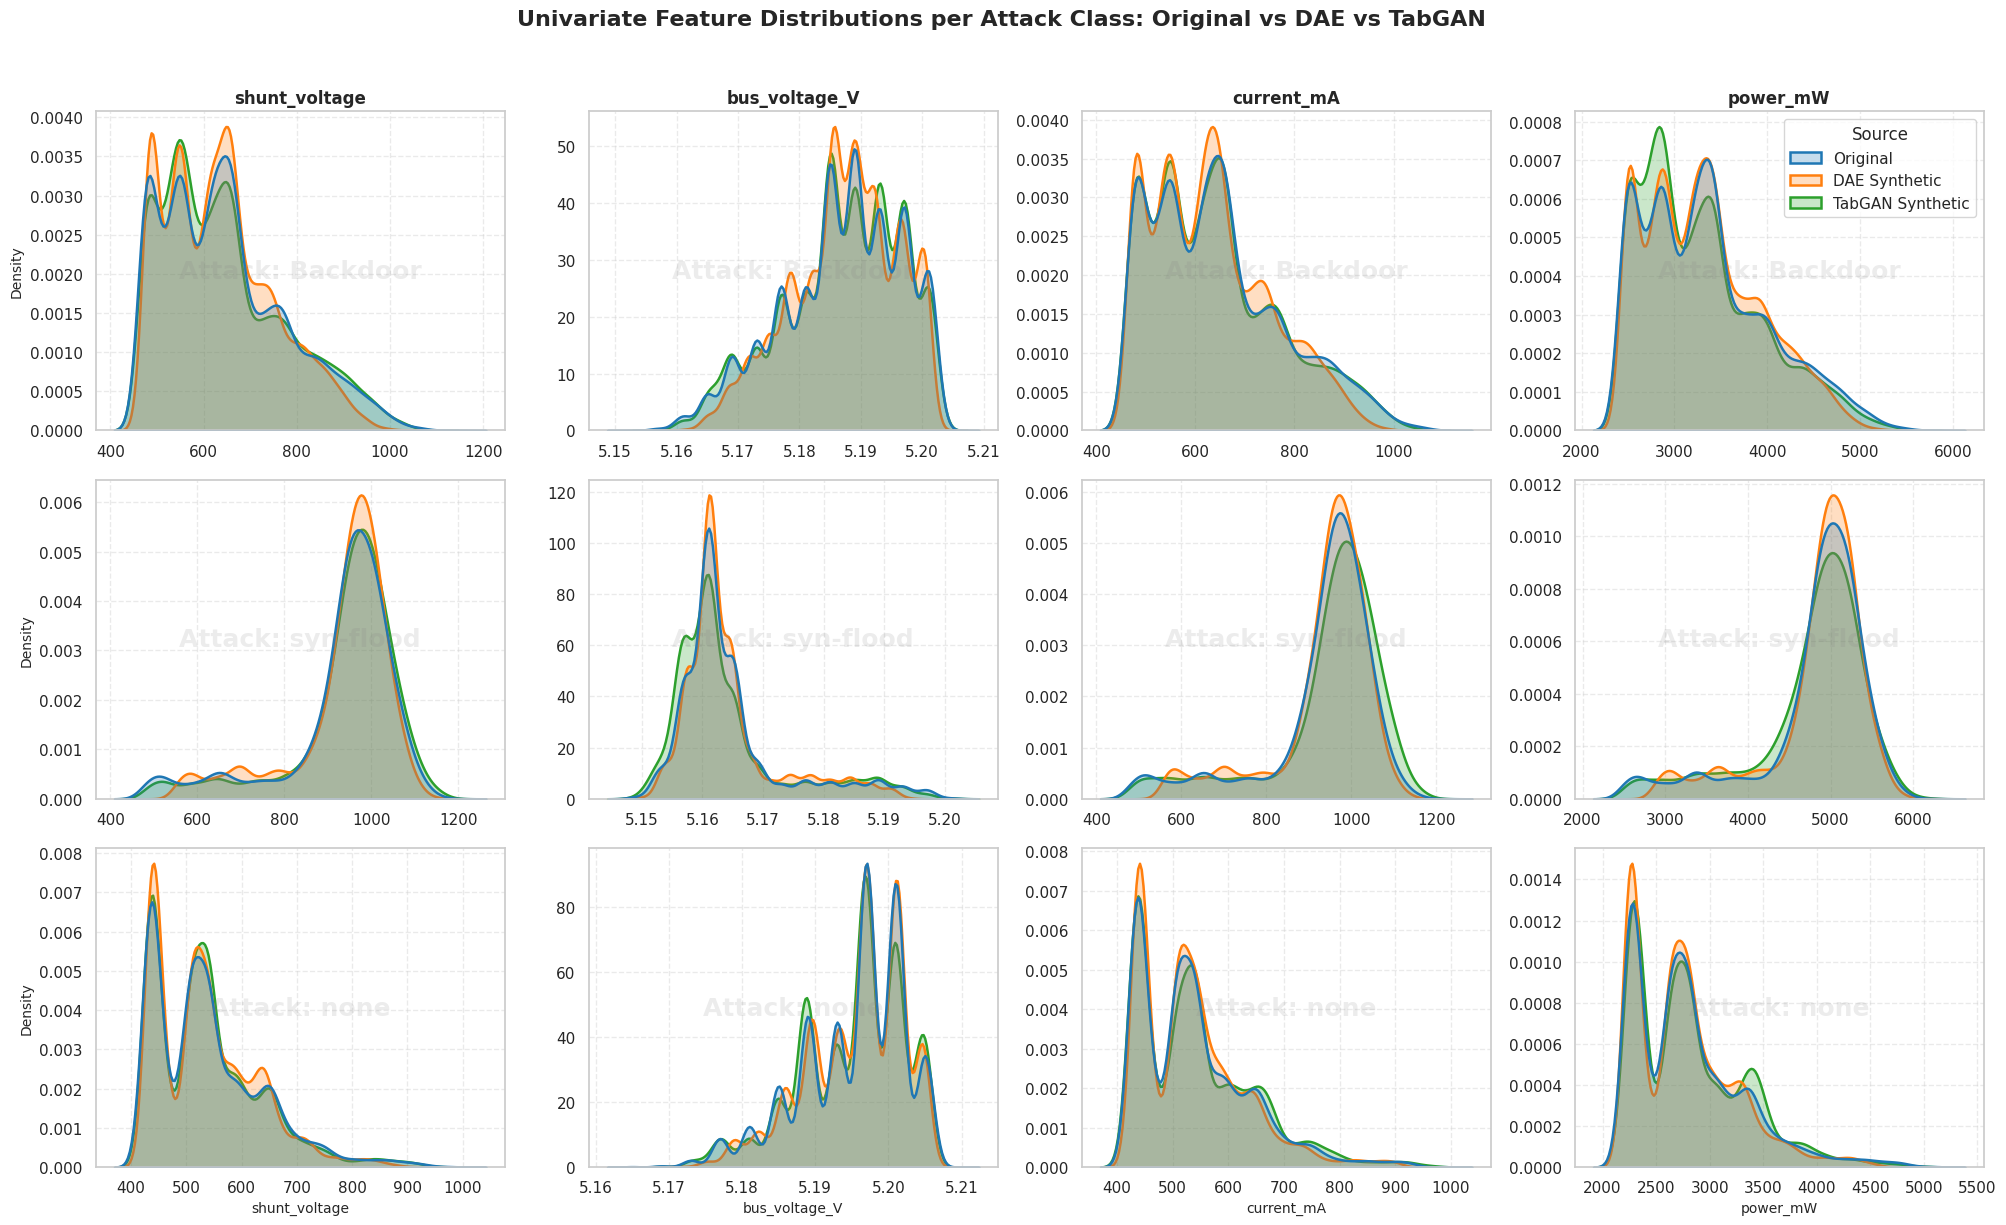

In [106]:
# Cell 8: Feature Distribution Comparison Split by Attack Label + Plain Text Values
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

continuous_cols = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
target_col = "Attack"
attack_labels = ["Backdoor", "syn-flood", "none"]

cols_to_extract = continuous_cols + [target_col]

df_orig_plot = df_orig_train[cols_to_extract].copy()
df_orig_plot["Source"] = "Original"

df_dae_plot = df_dae_train[cols_to_extract].copy()
df_dae_plot["Source"] = "DAE Synthetic"

df_tabgan_plot = df_tabgan_train[cols_to_extract].copy()
df_tabgan_plot["Source"] = "TabGAN Synthetic"

df_combined = pd.concat([df_orig_plot, df_dae_plot, df_tabgan_plot], ignore_index=True)

# --- Print Plain Numerical Summary ---
print("==================================================")
print(" FEATURE DISTRIBUTION SUMMARY STATS PER ATTACK ")
print("==================================================")

summary_stats = df_combined.groupby(["Attack", "Source"])[continuous_cols].agg(
    ["mean", "std", "min", "max"]
)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(summary_stats.round(4))
print("\n" + "="*50 + "\n")

# --- Plotting ---
fig, axes = plt.subplots(len(attack_labels), len(continuous_cols), figsize=(20, 12), sharey=False)

palette_dict = {
    "Original": "#1f77b4",
    "DAE Synthetic": "#ff7f0e",
    "TabGAN Synthetic": "#2ca02c"
}

for row_idx, attack in enumerate(attack_labels):
    df_attack = df_combined[df_combined[target_col] == attack]
    
    for col_idx, feature in enumerate(continuous_cols):
        ax = axes[row_idx, col_idx]
        
        sns.kdeplot(
            data=df_attack,
            x=feature,
            hue="Source",
            common_norm=False,
            fill=True,
            alpha=0.25,
            linewidth=1.8,
            palette=palette_dict,
            ax=ax,
            legend=(row_idx == 0 and col_idx == len(continuous_cols) - 1)
        )
        
        ax.text(
            0.5, 0.5, f"Attack: {attack}", 
            transform=ax.transAxes,
            fontsize=18, fontweight="bold", color="gray",
            alpha=0.15, ha="center", va="center"
        )
        
        if row_idx == 0:
            ax.set_title(feature, fontsize=12, fontweight="bold")
        ax.set_xlabel(feature if row_idx == len(attack_labels) - 1 else "", fontsize=10)
        ax.set_ylabel("Density" if col_idx == 0 else "", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Univariate Feature Distributions per Attack Class: Original vs DAE vs TabGAN", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

 OVERALL CORRELATION MATRICES 

--- Original Dataset Correlation ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9229      0.8700    0.8504
bus_voltage_V        -0.9229         1.0000     -0.9063   -0.8921
current_mA            0.8700        -0.9063      1.0000    0.9299
power_mW              0.8504        -0.8921      0.9299    1.0000

--- DAE Synthetic Correlation ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9380      0.8954    0.8816
bus_voltage_V        -0.9380         1.0000     -0.9253   -0.9139
current_mA            0.8954        -0.9253      1.0000    0.9461
power_mW              0.8816        -0.9139      0.9461    1.0000

--- TabGAN Synthetic Correlation ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.8474      0.8102    0.7904
bus_voltage_V        -0.8474         1.0000     -0.8326   -0.8173


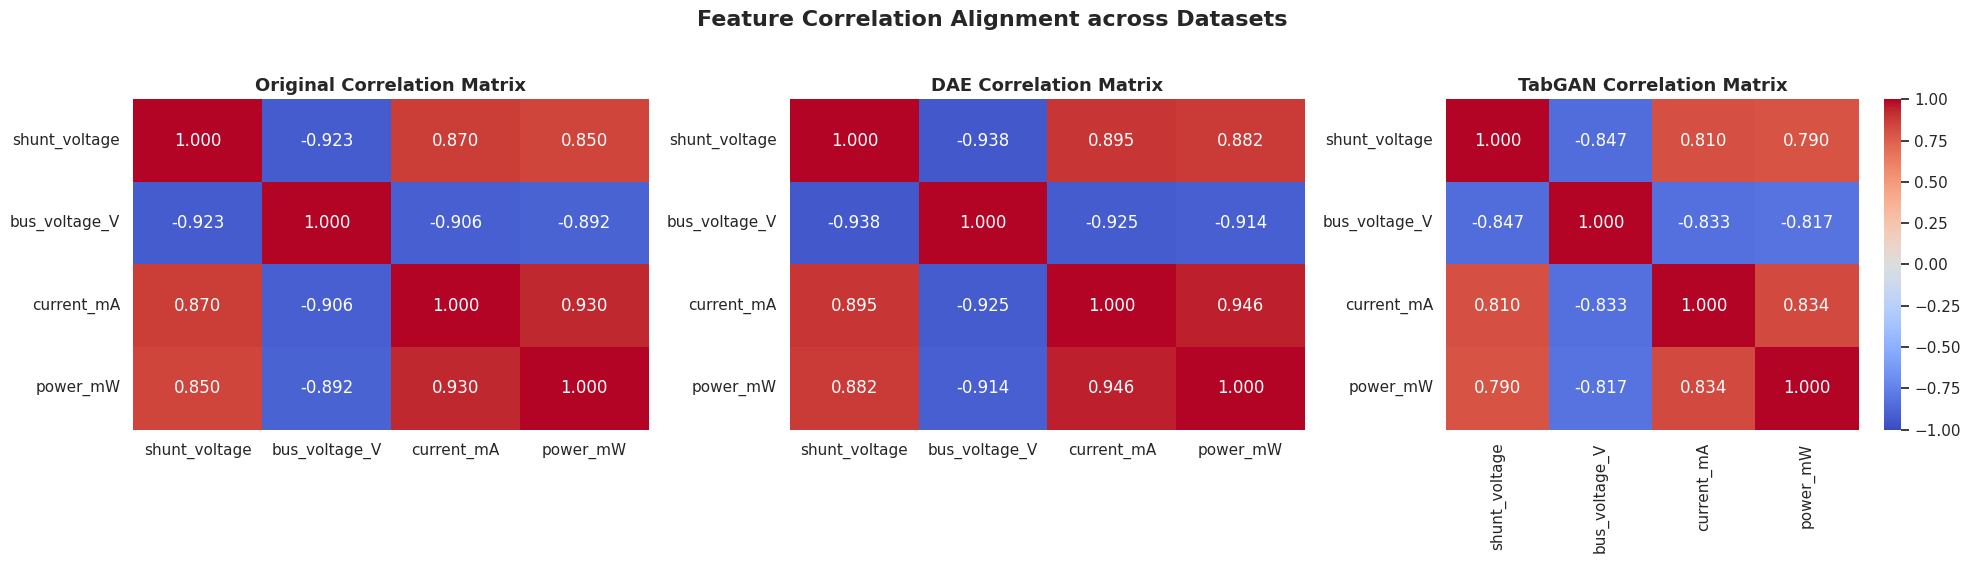

In [107]:
# Cell 9: Correlation Matrices Comparison + Plain Values
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_cols_corr = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]

corr_orig = df_orig_train[feature_cols_corr].corr()
corr_dae = df_dae_train[feature_cols_corr].corr()
corr_tabgan = df_tabgan_train[feature_cols_corr].corr()

# --- Print Plain Correlation Values ---
print("==========================================")
print(" OVERALL CORRELATION MATRICES ")
print("==========================================")
print("\n--- Original Dataset Correlation ---")
print(corr_orig.round(4))

print("\n--- DAE Synthetic Correlation ---")
print(corr_dae.round(4))

print("\n--- TabGAN Synthetic Correlation ---")
print(corr_tabgan.round(4))
print("\n" + "="*42 + "\n")

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

sns.heatmap(corr_orig, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Original Correlation Matrix", fontsize=13, fontweight="bold")

sns.heatmap(corr_dae, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title("DAE Correlation Matrix", fontsize=13, fontweight="bold")

sns.heatmap(corr_tabgan, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[2], cbar=True)
axes[2].set_title("TabGAN Correlation Matrix", fontsize=13, fontweight="bold")

plt.suptitle("Feature Correlation Alignment across Datasets", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

 CORRELATION MATRICES BY STATE 

--- Original | State: IDLE ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9735      0.9602    0.9566
bus_voltage_V        -0.9735         1.0000     -0.9705   -0.9673
current_mA            0.9602        -0.9705      1.0000    0.9757
power_mW              0.9566        -0.9673      0.9757    1.0000

--- DAE | State: IDLE ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9793      0.9684    0.9657
bus_voltage_V        -0.9793         1.0000     -0.9769   -0.9740
current_mA            0.9684        -0.9769      1.0000    0.9804
power_mW              0.9657        -0.9740      0.9804    1.0000

--- TabGAN | State: IDLE ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.9192      0.9089    0.9016
bus_voltage_V        -0.9192         1.0000     -0.9070   -0.9011
current_mA           

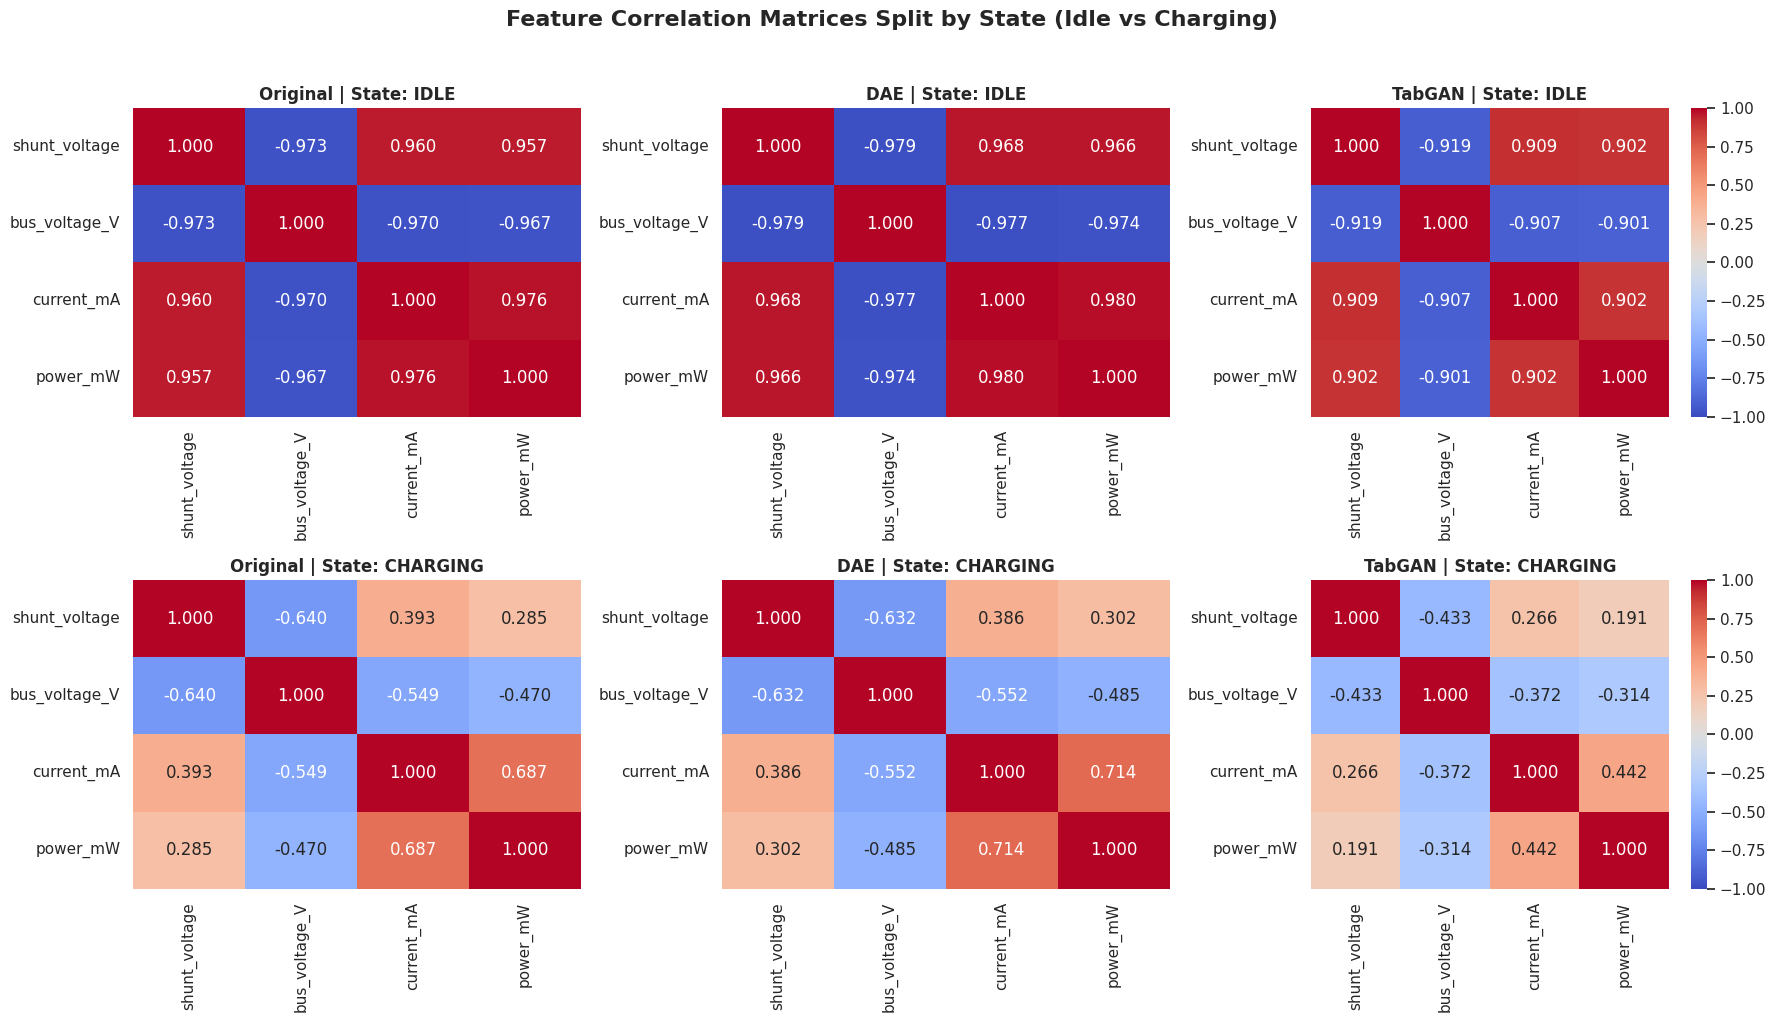

In [108]:
# Cell 10: Correlation Matrices Split by State (Idle vs Charging) + Plain Values
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_cols_corr = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]

datasets_dict = {
    "Original": df_orig_train,
    "DAE": df_dae_train,
    "TabGAN": df_tabgan_train
}

states = ["idle", "charging"]

# --- Print Plain Correlation Values ---
print("==========================================")
print(" CORRELATION MATRICES BY STATE ")
print("==========================================")

for state_val in states:
    for name, df in datasets_dict.items():
        df_filtered = df[df["State"] == state_val][feature_cols_corr]
        print(f"\n--- {name} | State: {state_val.upper()} ---")
        if not df_filtered.empty:
            print(df_filtered.corr().round(4))
        else:
            print("No data available.")
print("\n" + "="*42 + "\n")

# --- Plotting ---
fig, axes = plt.subplots(len(states), len(datasets_dict), figsize=(18, 10))

for row_idx, state_val in enumerate(states):
    for col_idx, (name, df) in enumerate(datasets_dict.items()):
        ax = axes[row_idx, col_idx]
        df_filtered = df[df["State"] == state_val][feature_cols_corr]
        
        if not df_filtered.empty:
            corr_matrix = df_filtered.corr()
            sns.heatmap(
                corr_matrix, 
                annot=True, 
                fmt=".3f", 
                cmap="coolwarm", 
                vmin=-1, 
                vmax=1, 
                ax=ax, 
                cbar=(col_idx == len(datasets_dict) - 1)
            )
        else:
            ax.text(0.5, 0.5, "No Data", ha="center", va="center")
            
        ax.set_title(f"{name} | State: {state_val.upper()}", fontsize=12, fontweight="bold")

plt.suptitle("Feature Correlation Matrices Split by State (Idle vs Charging)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

 CORRELATION MATRICES BY ATTACK TYPE 

--- Original | Attack: Backdoor ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.7732      0.5964    0.5277
bus_voltage_V        -0.7732         1.0000     -0.7122   -0.6561
current_mA            0.5964        -0.7122      1.0000    0.8014
power_mW              0.5277        -0.6561      0.8014    1.0000

--- DAE | Attack: Backdoor ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.7822      0.6108    0.5541
bus_voltage_V        -0.7822         1.0000     -0.7262   -0.6738
current_mA            0.6108        -0.7262      1.0000    0.8308
power_mW              0.5541        -0.6738      0.8308    1.0000

--- TabGAN | Attack: Backdoor ---
               shunt_voltage  bus_voltage_V  current_mA  power_mW
shunt_voltage         1.0000        -0.5836      0.4678    0.4046
bus_voltage_V        -0.5836         1.0000     -0.5712   -0.5146


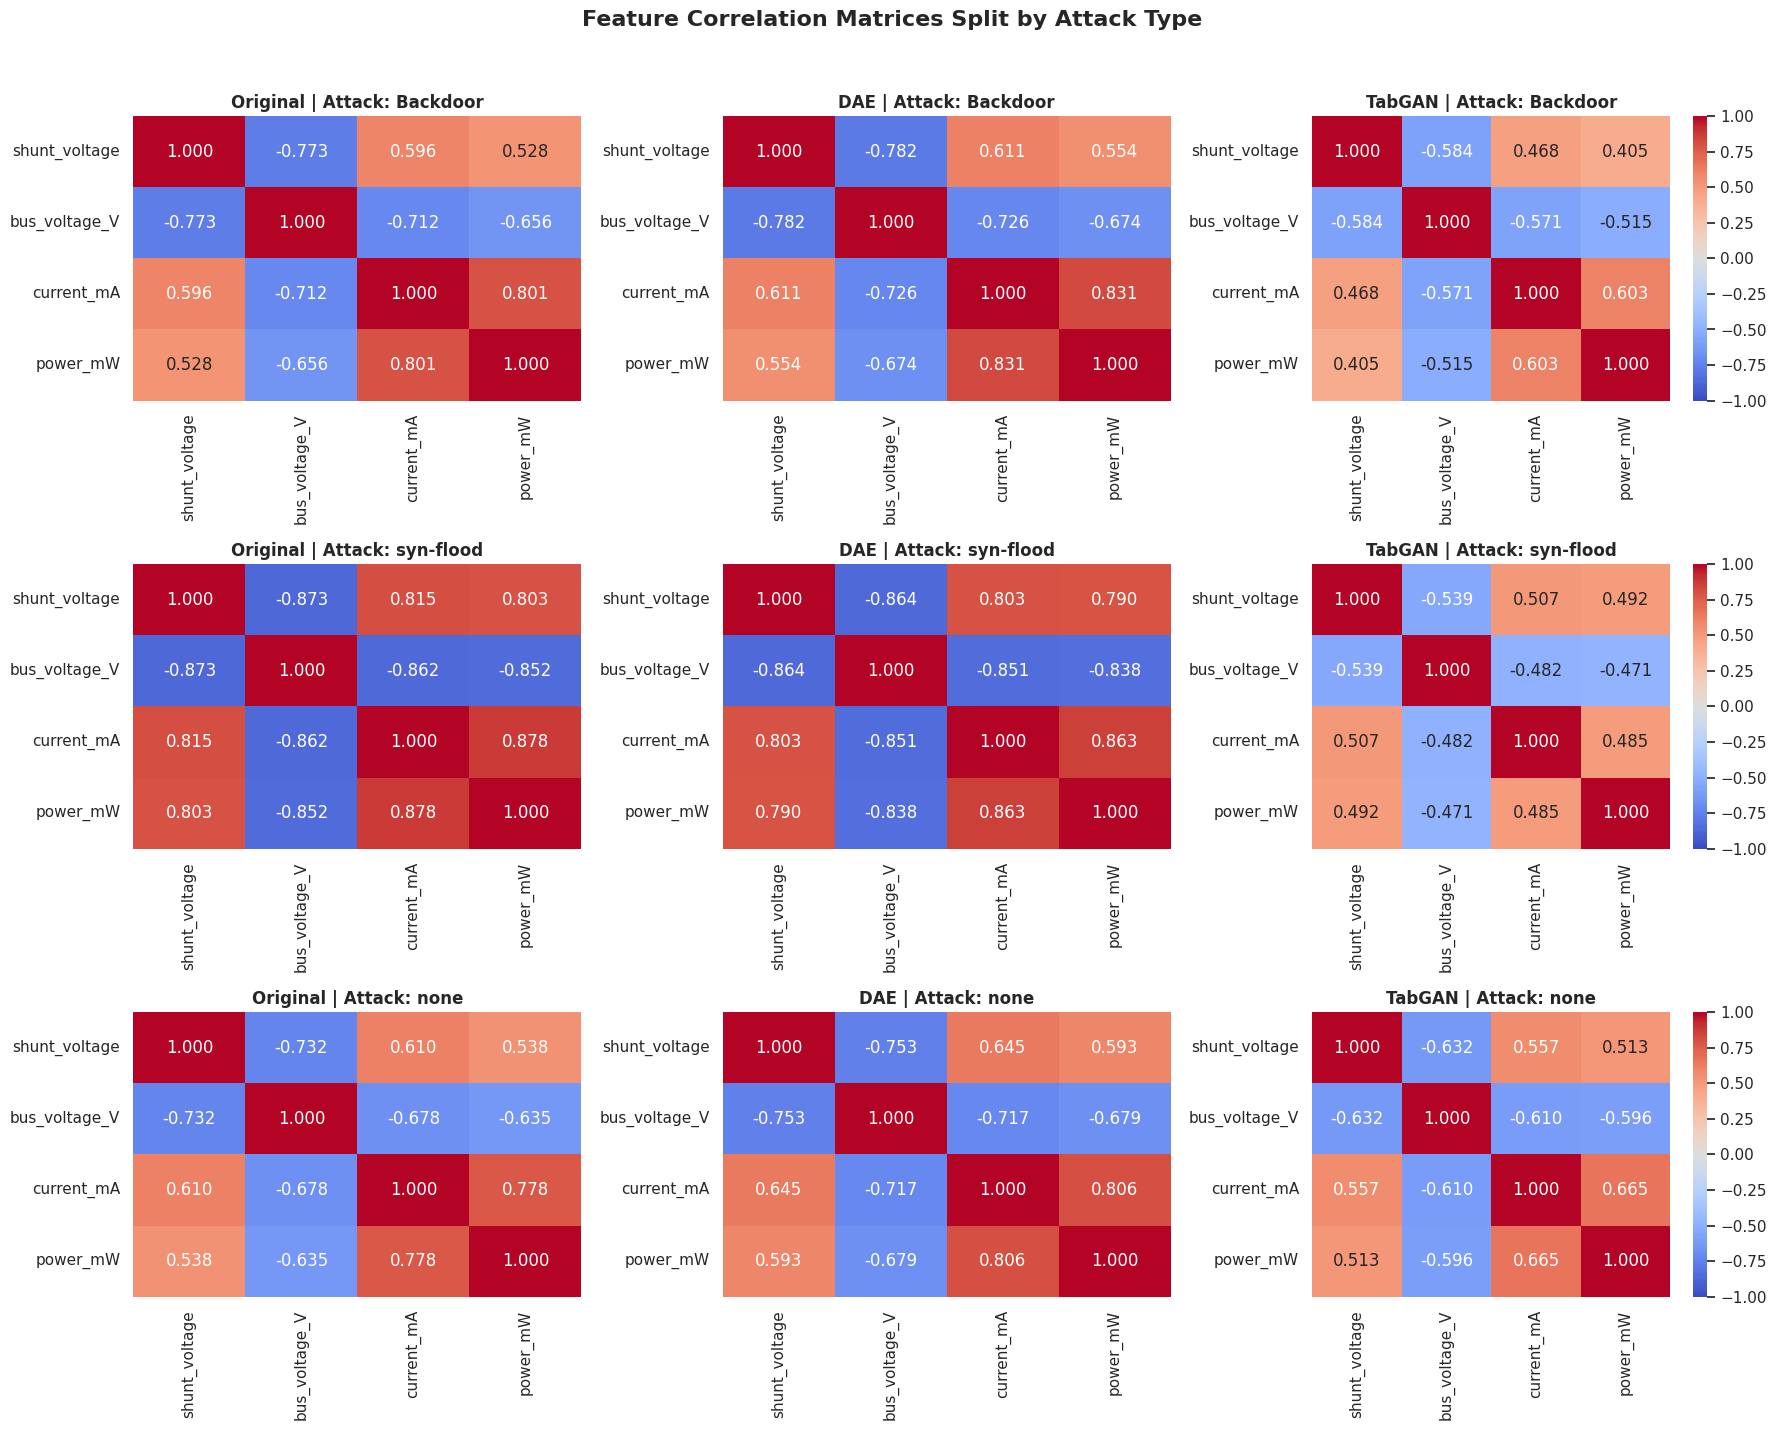

In [109]:
# Cell 11: Correlation Matrices Split by Attack Type + Plain Values
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

feature_cols_corr = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
attack_types = ["Backdoor", "syn-flood", "none"]

datasets_dict = {
    "Original": df_orig_train,
    "DAE": df_dae_train,
    "TabGAN": df_tabgan_train
}

# --- Print Plain Correlation Values ---
print("==========================================")
print(" CORRELATION MATRICES BY ATTACK TYPE ")
print("==========================================")

for attack_val in attack_types:
    for name, df in datasets_dict.items():
        df_filtered = df[df["Attack"] == attack_val][feature_cols_corr]
        print(f"\n--- {name} | Attack: {attack_val} ---")
        if not df_filtered.empty:
            print(df_filtered.corr().round(4))
        else:
            print("No data available.")
print("\n" + "="*42 + "\n")

# --- Plotting ---
fig, axes = plt.subplots(len(attack_types), len(datasets_dict), figsize=(18, 14))

for row_idx, attack_val in enumerate(attack_types):
    for col_idx, (name, df) in enumerate(datasets_dict.items()):
        ax = axes[row_idx, col_idx]
        df_filtered = df[df["Attack"] == attack_val][feature_cols_corr]
        
        if not df_filtered.empty:
            corr_matrix = df_filtered.corr()
            sns.heatmap(
                corr_matrix, 
                annot=True, 
                fmt=".3f", 
                cmap="coolwarm", 
                vmin=-1, 
                vmax=1, 
                ax=ax, 
                cbar=(col_idx == len(datasets_dict) - 1)
            )
        else:
            ax.text(0.5, 0.5, "No Data", ha="center", va="center")
            
        ax.set_title(f"{name} | Attack: {attack_val}", fontsize=12, fontweight="bold")

plt.suptitle("Feature Correlation Matrices Split by Attack Type", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

 PCA METRICS & COMPONENT MEANS 
Explained Variance Ratio: PC1 = 63.14%, PC2 = 31.63% (Total: 94.77%)

--- PCA Feature Loadings (Eigenvectors) ---
                   PC1     PC2
shunt_voltage  -0.4804  0.1162
bus_voltage_V   0.4914 -0.1141
current_mA     -0.4887  0.1202
power_mW       -0.4847  0.1146
State_charging  0.1644  0.6877
State_idle     -0.1644 -0.6877

--- Mean & Std of Principal Components per Dataset ---
                  PC1          PC2        
                 mean     std mean     std
Source                                    
DAE Synthetic    -0.0  1.9711  0.0  1.3657
Original         -0.0  1.9464  0.0  1.3776
TabGAN Synthetic  0.0  1.8971 -0.0  1.3664




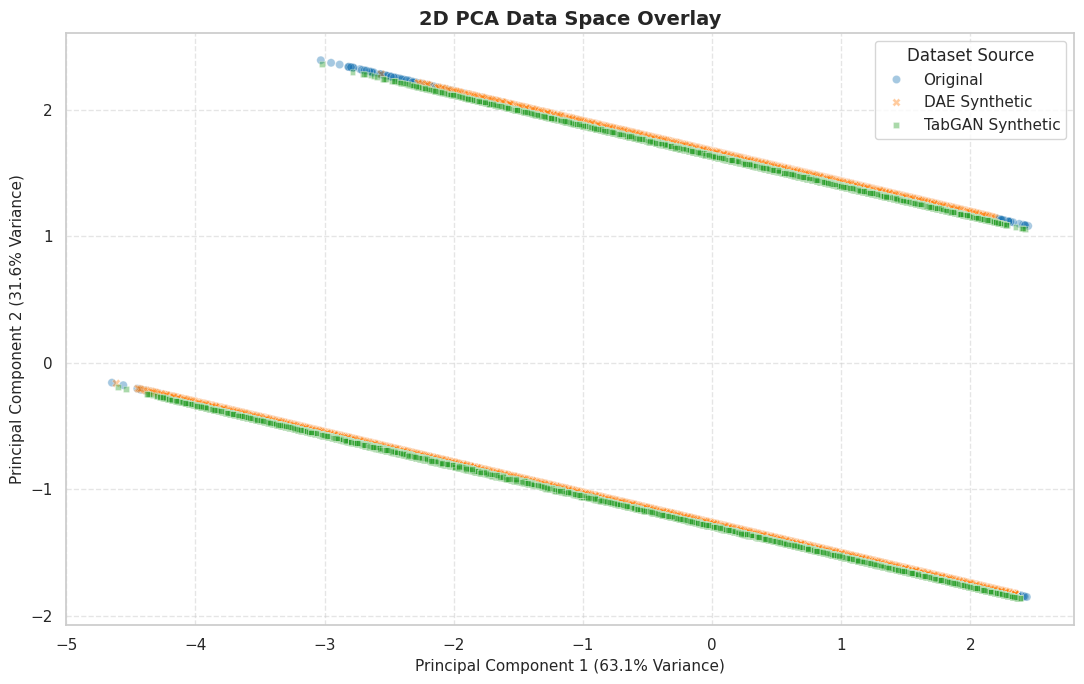

In [110]:
# Cell 12: Multivariate PCA Overlay Plot + Plain Values
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_orig_pca = pca.fit_transform(X_orig_train_scaled)
X_dae_pca = pca.transform(X_dae_train_scaled)
X_tabgan_pca = pca.transform(X_tabgan_train_scaled)

df_pca_orig = pd.DataFrame(X_orig_pca, columns=["PC1", "PC2"])
df_pca_orig["Source"] = "Original"

df_pca_dae = pd.DataFrame(X_dae_pca, columns=["PC1", "PC2"])
df_pca_dae["Source"] = "DAE Synthetic"

df_pca_tabgan = pd.DataFrame(X_tabgan_pca, columns=["PC1", "PC2"])
df_pca_tabgan["Source"] = "TabGAN Synthetic"

df_pca_all = pd.concat([df_pca_orig, df_pca_dae, df_pca_tabgan], ignore_index=True)

# --- Print Plain Numerical Summary ---
var_exp = pca.explained_variance_ratio_ * 100

print("==========================================")
print(" PCA METRICS & COMPONENT MEANS ")
print("==========================================")
print(f"Explained Variance Ratio: PC1 = {var_exp[0]:.2f}%, PC2 = {var_exp[1]:.2f}% (Total: {sum(var_exp):.2f}%)")

print("\n--- PCA Feature Loadings (Eigenvectors) ---")
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=feature_order)
print(loadings.round(4))

print("\n--- Mean & Std of Principal Components per Dataset ---")
pca_summary = df_pca_all.groupby("Source")[["PC1", "PC2"]].agg(["mean", "std"])
print(pca_summary.round(4))
print("\n" + "="*42 + "\n")

# --- Plotting ---
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_pca_all,
    x="PC1",
    y="PC2",
    hue="Source",
    style="Source",
    alpha=0.4,
    s=35,
    palette={"Original": "#1f77b4", "DAE Synthetic": "#ff7f0e", "TabGAN Synthetic": "#2ca02c"}
)

plt.title("2D PCA Data Space Overlay", fontsize=14, fontweight="bold")
plt.xlabel(f"Principal Component 1 ({var_exp[0]:.1f}% Variance)", fontsize=11)
plt.ylabel(f"Principal Component 2 ({var_exp[1]:.1f}% Variance)", fontsize=11)
plt.legend(title="Dataset Source", loc="best")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/yannic/Desktop/Master_rbg/Semester2/Forschungsarbeit 2/.venvDatasets/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not 

 MACRO ROC-AUC SCORE VALUES (At 200 Estimators) 

--- Original Dataset Model ---
  Train ROC-AUC:      0.988496
  OOB-Val ROC-AUC:    0.969598
  Real Test ROC-AUC:  0.969456

--- DAE Synthetic Model ---
  Train ROC-AUC:      0.999412
  OOB-Val ROC-AUC:    0.995101
  Real Test ROC-AUC:  0.926530

--- TabGAN Synthetic Model ---
  Train ROC-AUC:      0.992438
  OOB-Val ROC-AUC:    0.974574
  Real Test ROC-AUC:  0.975493




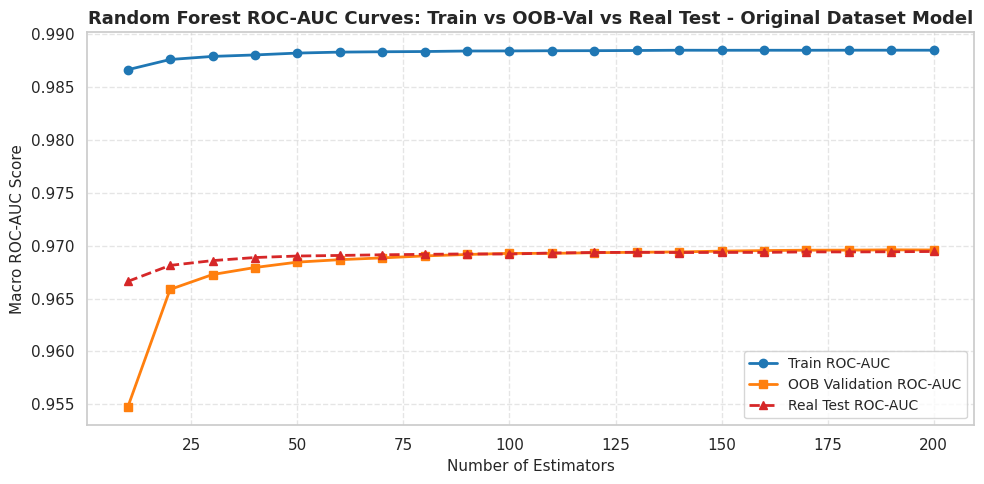

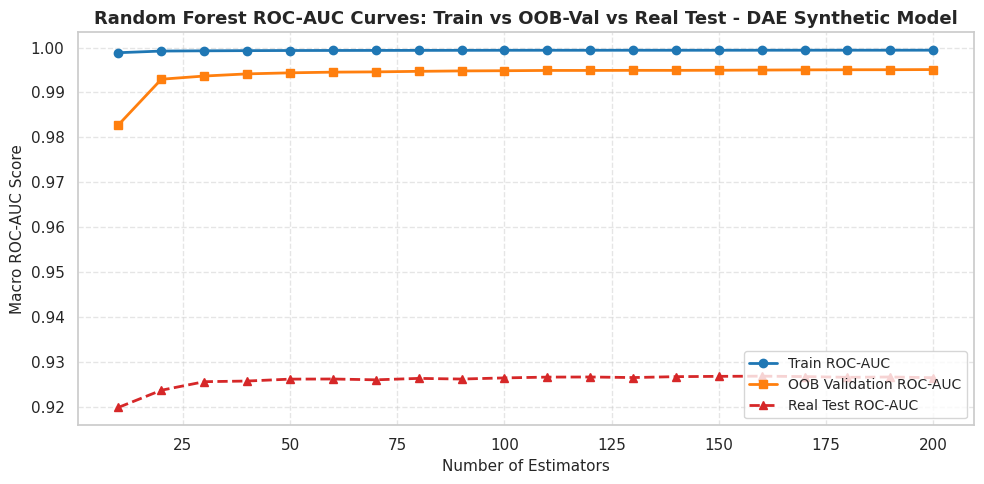

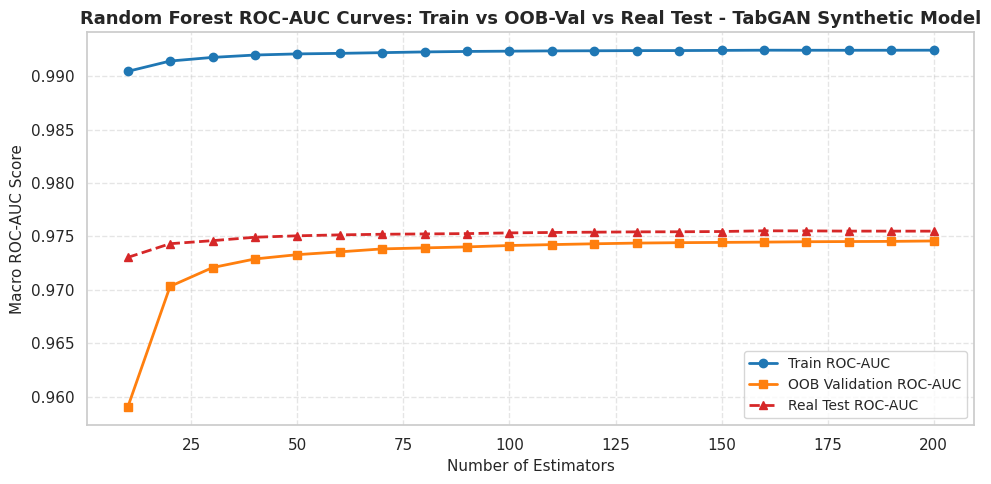

In [114]:
# Cell (Fixed & Robust): Macro ROC-AUC Evaluation Curves
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

SEED = 42

rf_params = {
    "bootstrap": True,
    "max_depth": None,
    "max_features": "sqrt",
    "min_samples_leaf": 1,
    "min_samples_split": 20,
    "criterion": "gini",
    "random_state": SEED,
    "n_jobs": -1,
    "oob_score": True,
    "warm_start": True
}

n_estimators_range = list(range(10, 201, 10))

def enforce_exact_probabilities(probs):
    """
    Stellt sicher, dass alle Wahrscheinlichkeiten positiv sind 
    und die Zeilensumme exakt (ohne Floating-Point-Fehler) 1.0 ergibt.
    """
    probs = np.copy(probs)
    # NaNs durch gleichmäßige Verteilung ersetzen
    if np.isnan(probs).any():
        probs = np.nan_to_num(probs, nan=1.0 / probs.shape[1])
    
    # Negative Werte abfangen
    probs = np.clip(probs, 0.0, 1.0)
    
    # Vorläufige Normalisierung
    row_sums = probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    probs = probs / row_sums
    
    # Exakte mathematische Korrektur der letzen Spalte gegen Floating-Point-Fehler
    probs[:, -1] = 1.0 - probs[:, :-1].sum(axis=1)
    return probs

def collect_rf_roc_auc_curve(X_train, y_train, X_test, y_test):
    """
    Berechnet Macro ROC-AUC Werte über n_estimators mit robuster
    Wahrscheinlichkeits-Bereinigung.
    """
    train_rocs = []
    val_rocs = []
    test_rocs = []
    
    model = RandomForestClassifier(**rf_params)
    
    for n in n_estimators_range:
        model.set_params(n_estimators=n)
        model.fit(X_train, y_train)
        
        # 1. Train ROC-AUC
        y_train_prob = enforce_exact_probabilities(model.predict_proba(X_train))
        train_roc = roc_auc_score(y_train, y_train_prob, multi_class="ovr", average="macro")
        train_rocs.append(train_roc)
        
        # 2. OOB Validation ROC-AUC
        oob_prob = enforce_exact_probabilities(model.oob_decision_function_)
        val_roc = roc_auc_score(y_train, oob_prob, multi_class="ovr", average="macro")
        val_rocs.append(val_roc)
        
        # 3. Real Test Set ROC-AUC
        y_test_prob = enforce_exact_probabilities(model.predict_proba(X_test))
        test_roc = roc_auc_score(y_test, y_test_prob, multi_class="ovr", average="macro")
        test_rocs.append(test_roc)
        
    return train_rocs, val_rocs, test_rocs

# Berechne ROC-Kurven
orig_train_roc, orig_val_roc, orig_test_roc = collect_rf_roc_auc_curve(
    X_orig_train_scaled, y_orig_train, X_orig_test_scaled_orig, y_orig_test
)

dae_train_roc, dae_val_roc, dae_test_roc = collect_rf_roc_auc_curve(
    X_dae_train_scaled, y_dae_train, X_orig_test_scaled_dae, y_orig_test
)

tabgan_train_roc, tabgan_val_roc, tabgan_test_roc = collect_rf_roc_auc_curve(
    X_tabgan_train_scaled, y_tabgan_train, X_orig_test_scaled_tabgan, y_orig_test
)

roc_curve_data = [
    ("Original Dataset Model", orig_train_roc, orig_val_roc, orig_test_roc),
    ("DAE Synthetic Model", dae_train_roc, dae_val_roc, dae_test_roc),
    ("TabGAN Synthetic Model", tabgan_train_roc, tabgan_val_roc, tabgan_test_roc),
]

# --- Print Plain Numerical Values ---
print("==========================================")
print(" MACRO ROC-AUC SCORE VALUES (At 200 Estimators) ")
print("==========================================")
for title, train_r, val_r, test_r in roc_curve_data:
    print(f"\n--- {title} ---")
    print(f"  Train ROC-AUC:      {train_r[-1]:.6f}")
    print(f"  OOB-Val ROC-AUC:    {val_r[-1]:.6f}")
    print(f"  Real Test ROC-AUC:  {test_r[-1]:.6f}")
print("\n" + "="*42 + "\n")

# --- Plotting ---
for title, train_rocs, val_rocs, test_rocs in roc_curve_data:
    plt.figure(figsize=(10, 5))
    plt.plot(n_estimators_range, train_rocs, marker="o", linewidth=2, label="Train ROC-AUC", color="#1f77b4")
    plt.plot(n_estimators_range, val_rocs, marker="s", linewidth=2, label="OOB Validation ROC-AUC", color="#ff7f0e")
    plt.plot(n_estimators_range, test_rocs, marker="^", linewidth=2, label="Real Test ROC-AUC", color="#d62728", linestyle="--")
    
    plt.xlabel("Number of Estimators", fontsize=11)
    plt.ylabel("Macro ROC-AUC Score", fontsize=11)
    plt.title(f"Random Forest ROC-AUC Curves: Train vs OOB-Val vs Real Test - {title}", fontsize=13, fontweight="bold")
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()